# **MScFE 660: Risk Management (2025/06)**
## Student Group: **10144**
## Group Work Project: **1**
### Members:
1. **Miklos Lammel**
2. **Dipanshu Sharma**
3. **Bianka Toneva**

## **Install and then import python packages**

In [1]:
# installing the required libraries
!pip install fredapi

# importing the required libraries

import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
import yfinance as yf

import requests
import seaborn as sns
import json
from statsmodels.graphics.tsaplots import plot_acf

from datetime import date

import warnings
warnings.filterwarnings('ignore')

## **Step 3 - Data import**
Identify, import, structure, and graph macroeconomic, microeconomic, and geopolitical variables that affect the price of oil globally.

See full list in Step 4


- Geopolitical Risk Index (GPR) - https://www.policyuncertainty.com/gpr.html (1985 - 2025 monthly data)

- Energy Uncertainty Index (EUI) - https://www.policyuncertainty.com/energy_uncertainty.html (1996-2023 monthly data)

- Oil Price (WTI Crude) - From Yahoo Finance (CL=F) (2000 - 2025 daily data)

- US GDP Growth Rate (US) - (Macro) From FRED.

- US CPI (Inflation proxy) - (Macro) From FRED.

- Refinery Utilization Rate (FRED) - a proxy for downstream oil demand



### **Get geopolitcal data (GPR, EUI)**

Start date: 1985-01-01 00:00:00
End date: 2025-06-01 00:00:00


,GPR
month,
1985-01-01,102.173378
1985-02-01,117.102020
1985-03-01,124.778152
1985-04-01,87.929001
1985-05-01,103.262848


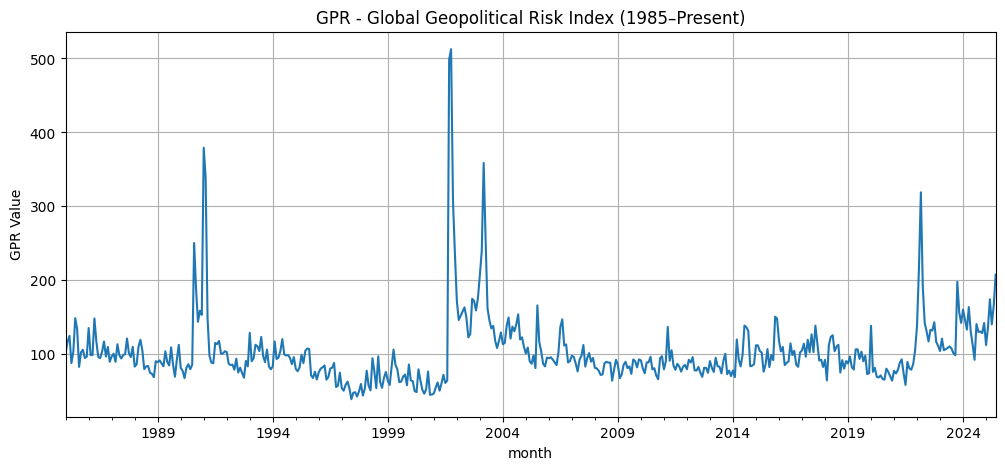

In [2]:
# getting Geopolitical Risk Index - GPR (1985 - 2025)

# downloading the dataset
url = "https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls"
df = pd.read_excel(url) # top row is month and GPR
df['month'] = pd.to_datetime(df['month'], format='%d/%m/%Y')
df.set_index('month', inplace=True)
gpr = df[['GPR']]
gpr = gpr[gpr.index >= '1985-01-01']

date_from = gpr.first_valid_index()
date_to = gpr.last_valid_index()
print("Start date:", date_from)
print("End date:", date_to)
display(gpr.head())

# plotting the GPR series
gpr.plot(title='GPR - Global Geopolitical Risk Index (1985–Present)', figsize=(12, 5), legend=False)
plt.ylabel('GPR Value')
plt.grid(True)
plt.show()

Start date: 1996-01-01
End date: 2023-11-01


,Energy_Uncertainty_Index
Date,
1996-01-01,0.358232
1996-02-01,0.373172
1996-03-01,0.203098
1996-04-01,0.317945
1996-05-01,0.711228


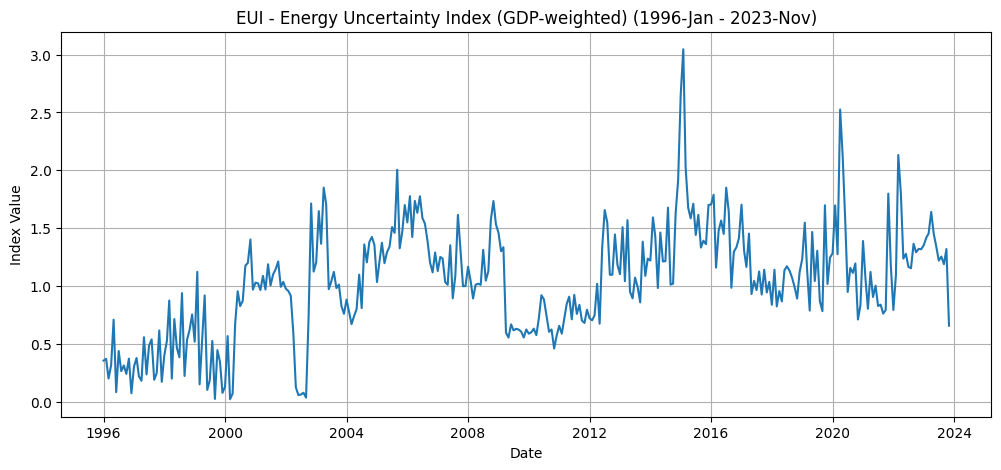

In [3]:
# getting Energy Uncertainty Risk Index - EUI (1996-2023 monthly data)


# downloading the dataset (excel)
url = "https://www.policyuncertainty.com/media/Energy-Related%20Uncertainty%20Indexes.xlsx"
sheet_name = "Global Average EUI Indexes"

df = pd.read_excel(url, sheet_name=sheet_name, header=2, converters={'Date': str})
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%d-%m %H:%M:%S', errors='coerce')
df['Date'] = df['Date'].dt.date
df.set_index('Date', inplace=True)

# extracting the energy index
energy_index = df[['global_EUI_GDP_weighted']]
energy_index.rename(columns={'global_EUI_GDP_weighted': 'Energy_Uncertainty_Index'}, inplace=True)

# perid of the downloaded dataset
date_from = energy_index.first_valid_index()
date_to = energy_index.last_valid_index()
print("Start date:", date_from)
print("End date:", date_to)
display(energy_index.head())

# plotting the EUI series
energy_index.plot(title=f"EUI - Energy Uncertainty Index (GDP-weighted) ({date_from.strftime('%Y-%b')} - {date_to.strftime('%Y-%b')})", figsize=(12, 5), legend=False)
plt.ylabel('Index Value')
plt.grid(True)
plt.show()

### **Get FRED data (CPI, GDP)**

CPI (Consumer Price Index)


,US CPI
1947-01-01,21.48
1947-02-01,21.62
1947-03-01,22.00
1947-04-01,22.00
1947-05-01,21.95


GDP (Gross Domestic Product)


,US GDP Growth Rate
1947-04-01,-1.0
1947-07-01,-0.8
1947-10-01,6.4
1948-01-01,6.2
1948-04-01,6.8


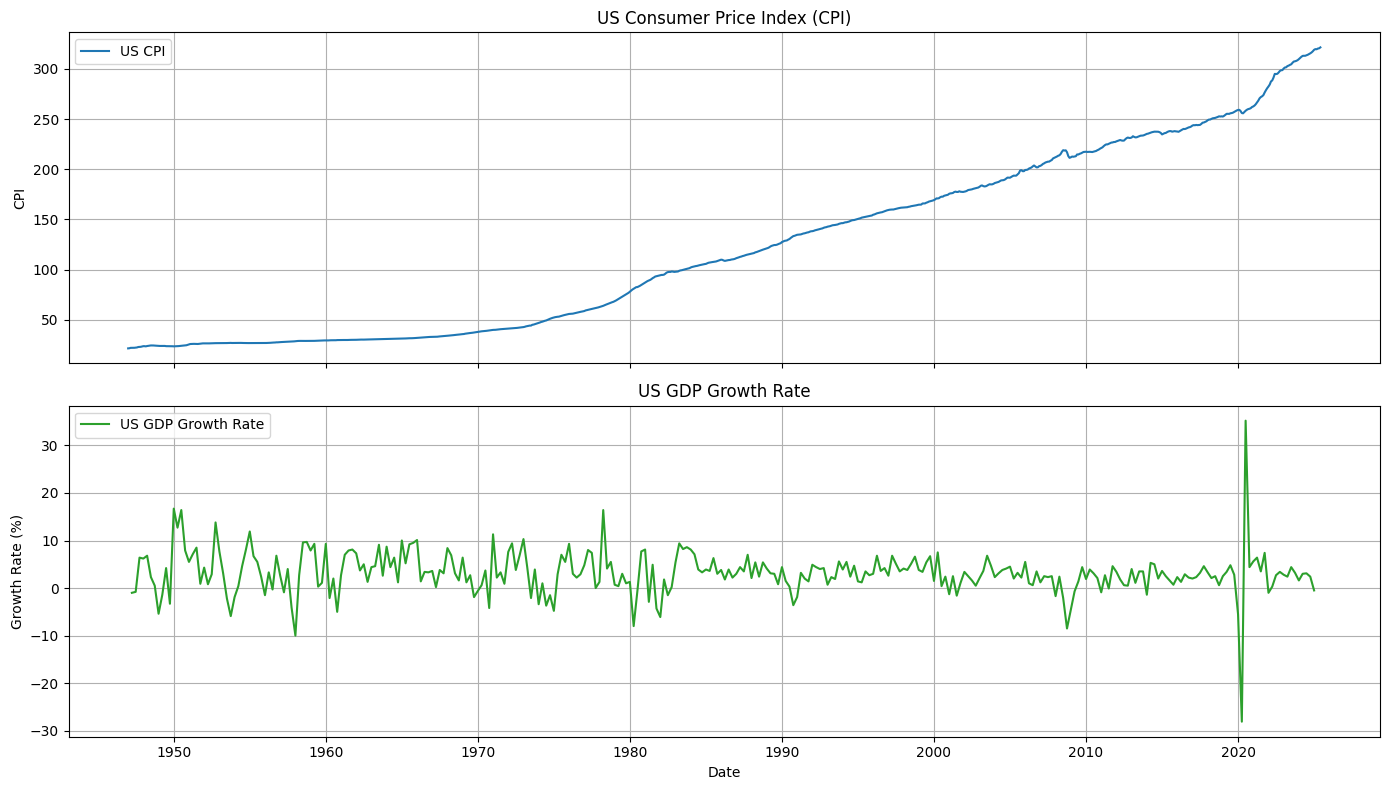

In [4]:
FRED_API_KEY = '1eca31140fb3700173f5c8b43fecbf97'
fred = Fred(api_key=FRED_API_KEY)

# retrieving US CPI (Consumer Price Index) and US GDP (Gross Domestic Product) data
cpi = fred.get_series('CPIAUCSL')
gdp = fred.get_series('A191RL1Q225SBEA')
cpi.name = 'US CPI'
gdp.name = 'US GDP Growth Rate'

print("CPI (Consumer Price Index)")
display(cpi.head())

print("GDP (Gross Domestic Product)")
display(gdp.head())

# plotting US CPI and GDP series
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(cpi, label=cpi.name, color='tab:blue')
ax1.set_title('US Consumer Price Index (CPI)')
ax1.set_ylabel('CPI')
ax1.grid(True)
ax1.legend()

ax2.plot(gdp, label=gdp.name, color='tab:green')
ax2.set_title('US GDP Growth Rate')
ax2.set_xlabel('Date')
ax2.set_ylabel('Growth Rate (%)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

### **Get WTI close price**

,WTI_Close
Date,
2000-08-23,32.049999
2000-08-24,31.629999
2000-08-25,32.049999
2000-08-28,32.869999
2000-08-29,32.720001


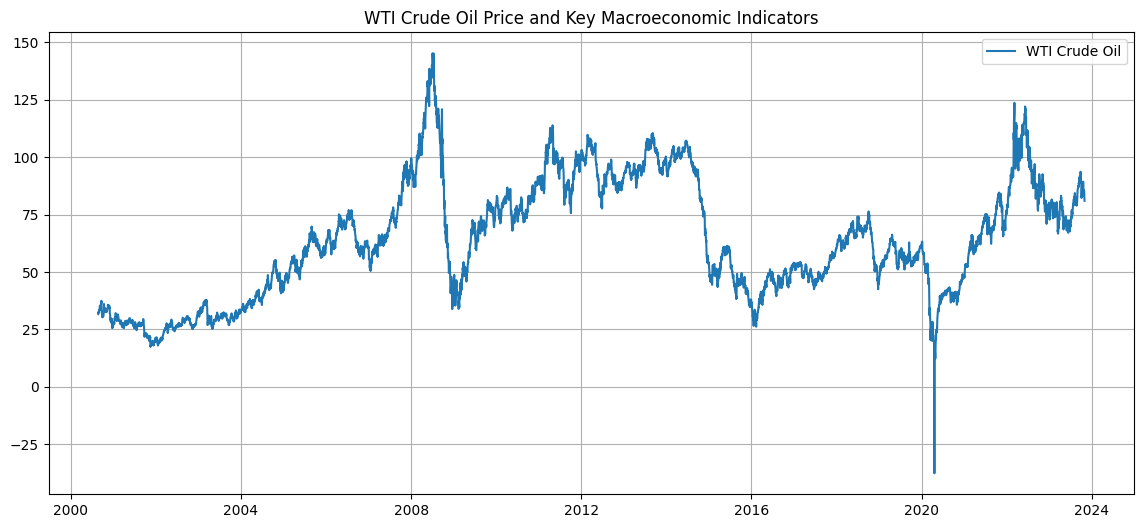

In [5]:
# downloading WTI Crude from Yahoo finance
wti = yf.download('CL=F', start='1996-01-01', end='2023-11-01', progress=False, auto_adjust = True)
wti = wti[('Close', 'CL=F')].rename('WTI_Close').to_frame()
display(wti.head())

# plotting the WTI series
plt.figure(figsize=(14, 6))
plt.title('WTI Crude Oil Price and Key Macroeconomic Indicators')
plt.plot(wti['WTI_Close'], label='WTI Crude Oil')
plt.legend()
plt.grid(True)
plt.show()

#### **Get Brent Oil prices - only available from 2007 - will not be used.**

,Brent_Close
Date,
2007-07-30,75.739998
2007-07-31,77.050003
2007-08-01,75.349998
2007-08-02,75.760002
2007-08-03,74.750000


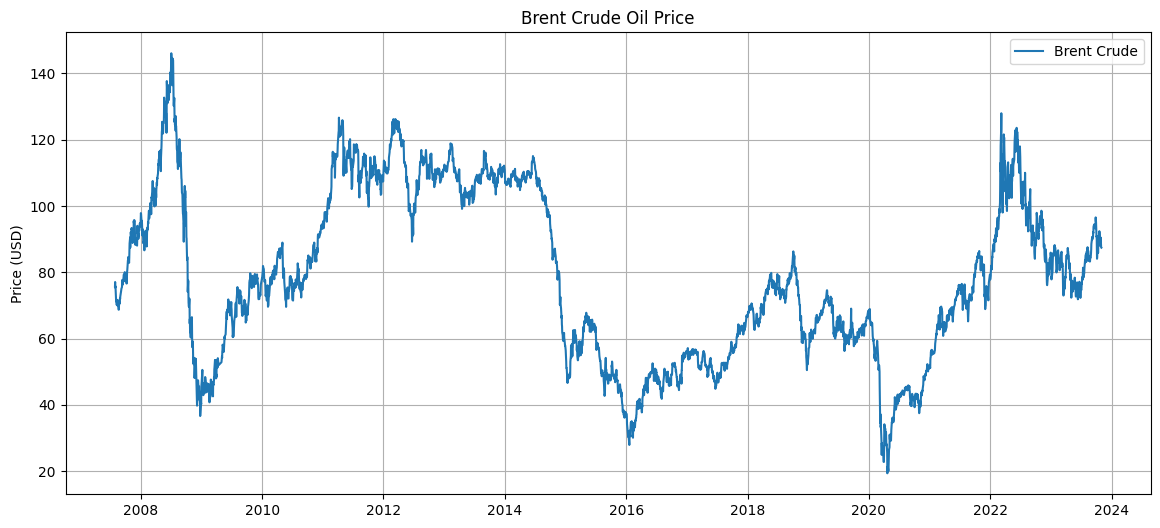

In [6]:
# downloading Brent crude oil prices from Yahoo Finance
brent = yf.download('BZ=F', start='1996-01-01', end='2023-11-01', progress=False, auto_adjust=True)
brent = brent[('Close','BZ=F')].rename('Brent_Close').to_frame()
display(brent.head())

# plotting the Brent series
plt.figure(figsize=(14, 6))
plt.title('Brent Crude Oil Price')
plt.plot(brent['Brent_Close'], label='Brent Crude')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

### **Get VIX index**

,VIX_Close
Date,
1996-01-02,12.19
1996-01-03,12.10
1996-01-04,13.78
1996-01-05,13.58
1996-01-08,13.11


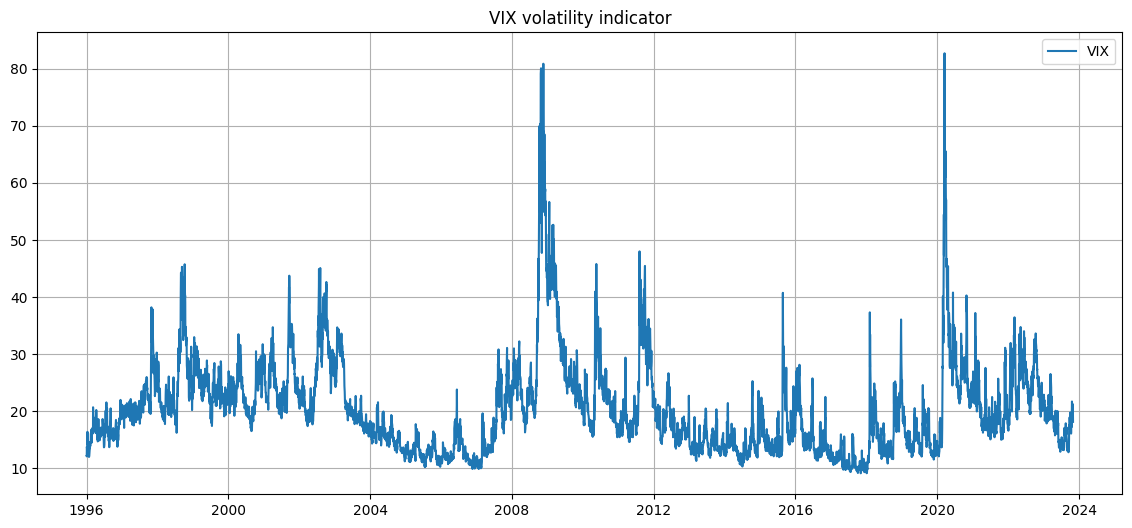

In [7]:
# downloading VIX index from Yahoo finance
vix = yf.download('^VIX', start='1996-01-01', end='2023-11-01', progress=False, auto_adjust = True)
vix = vix[('Close', '^VIX')].rename('VIX_Close').to_frame()
display(vix.head())

# plotting the VIX series
plt.figure(figsize=(14, 6))
plt.title('VIX volatility indicator')
plt.plot(vix['VIX_Close'], label='VIX')
plt.legend()
plt.grid(True)
plt.show()

### **Get US Dollar Index (DXY)**

,DXY_Close
Date,
1996-01-01,84.760002
1996-01-02,84.690002
1996-01-03,85.110001
1996-01-04,85.220001
1996-01-05,85.059998


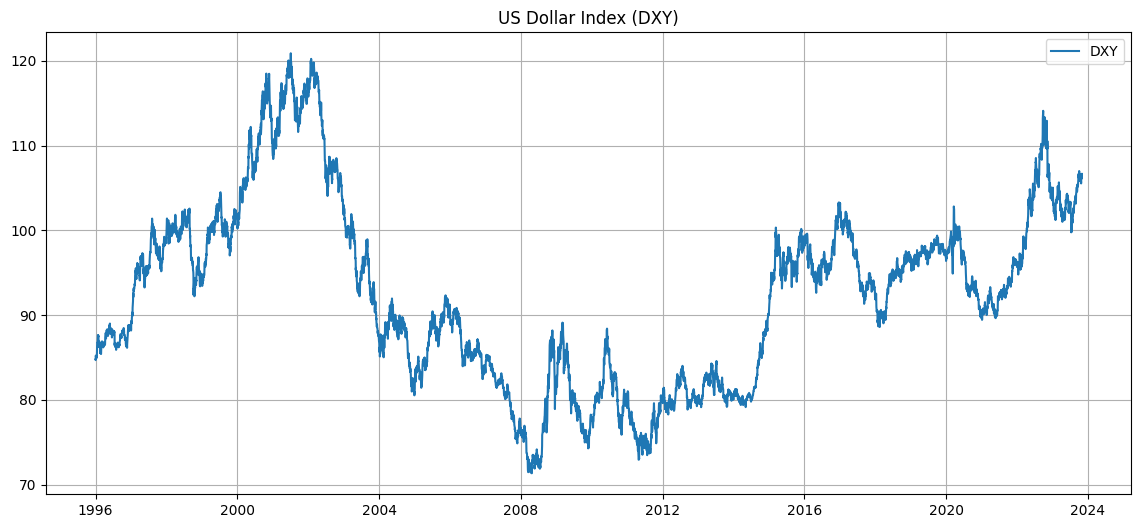

In [8]:
# downloading DXY (US Dollar Index) from Yahoo finance
dxy = yf.download('DX-Y.NYB', start='1996-01-01', end='2023-11-01', progress=False, auto_adjust=True)
dxy = dxy[('Close', 'DX-Y.NYB')].rename('DXY_Close').to_frame()
display(dxy.head())

# plotting the DXY series
plt.figure(figsize=(14, 6))
plt.title('US Dollar Index (DXY)')
plt.plot(dxy['DXY_Close'], label='DXY')
plt.legend()
plt.grid(True)
plt.show()


### **Downstream oil demand - Refinery Utilization**

Refinery Utilization Rate (FRED)
Start date: 1991-07-01 00:00:00
End date: 2025-06-01 00:00:00


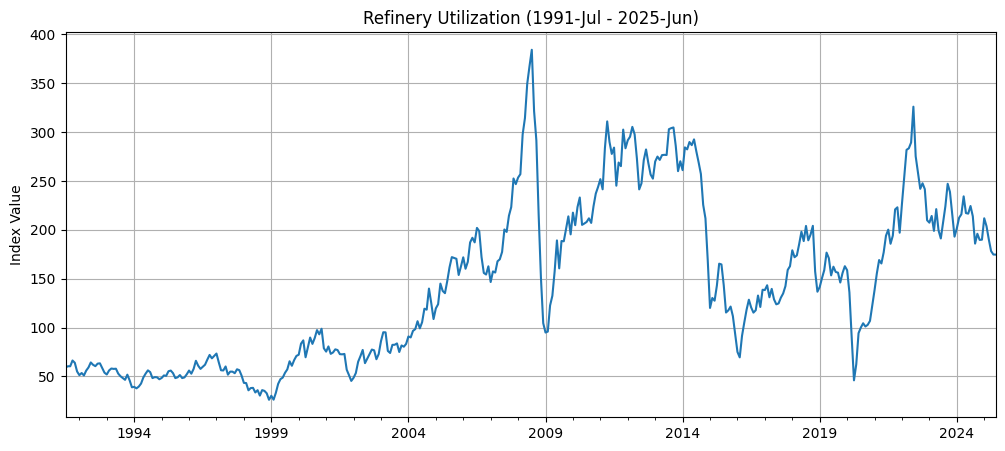

In [9]:
FRED_API_KEY = '1eca31140fb3700173f5c8b43fecbf97'
fred = Fred(api_key=FRED_API_KEY)

rur = fred.get_series('WPU056101')
rur.name = 'Refinery Utilization rate'
print("Refinery Utilization Rate (FRED)")

# perid of the downloaded dataset
date_from = rur.first_valid_index()
date_to = rur.last_valid_index()
print("Start date:", date_from)
print("End date:", date_to)

# plotting the RUR series
rur.plot(title=f"Refinery Utilization ({date_from.strftime('%Y-%b')} - {date_to.strftime('%Y-%b')})", figsize=(12, 5), legend=False)
plt.ylabel('Index Value')
plt.grid(True)
plt.show()

### **WCESTUS1 - Weekly Crude Oil Ending Stock US - Proxy for demand and supply**

US Crude Oil stock - The total commercial crude oil inventories held in the U.S., measured weekly, excluding emergency government stockpiles (SPR)

Proxy for oil demand because change in the stock reflect demand indirectly, especially in the short term.

If inventories rise, it could mean Production (or imports) > consumption ⇒ lower demand.

If inventories fall, it usually suggests: Consumption > production ⇒ higher demand.

Because inventories act as a buffer, they respond to the net effect of supply and demand. So when production is relatively stable, a drop in inventories often reflects stronger downstream consumption, i.e., more demand by refineries and end users.

,WCESTUS1
Date,
1982-08-20,338764
1982-08-27,336138
1982-09-24,335586
1982-10-01,334786
1982-10-08,335260


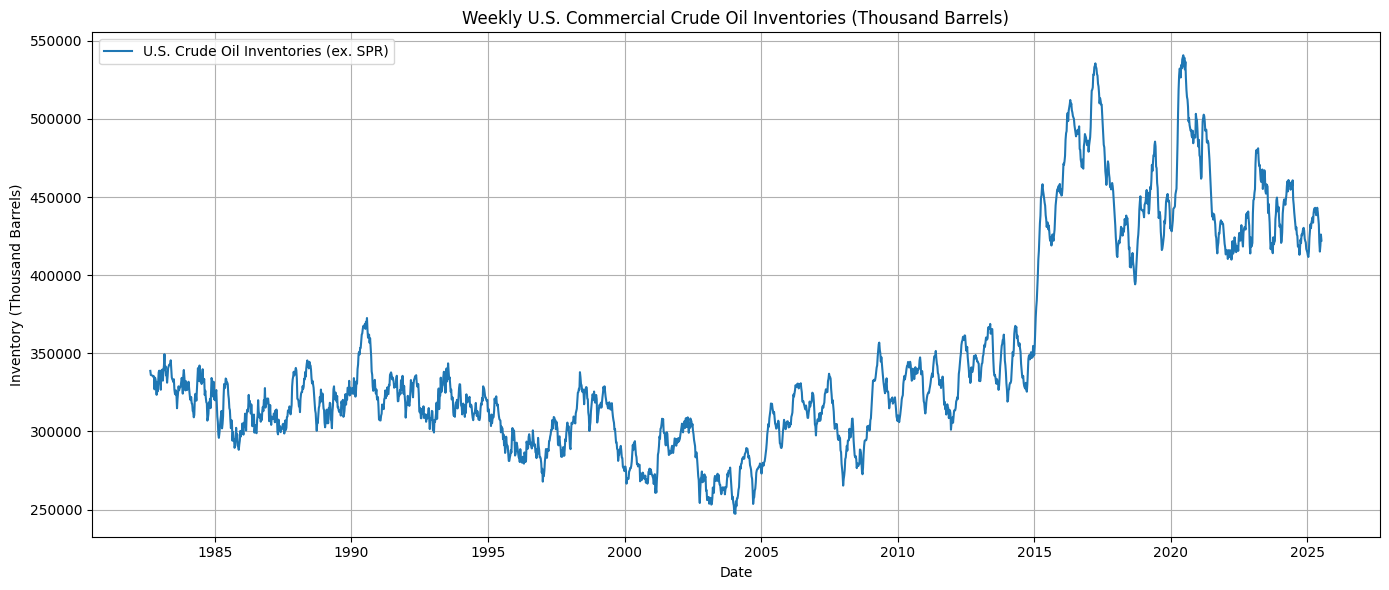

In [10]:
url = "https://www.eia.gov/dnav/pet/hist_xls/WCESTUS1w.xls"

# 'Data 1' sheet, skipping the first 3 rows
wcest = pd.read_excel(url, sheet_name='Data 1', skiprows=2)
wcest = wcest.dropna(subset=['Date'])
wcest['Date'] = pd.to_datetime(wcest['Date'], format='%b %d, %Y')
wcest = wcest.rename(columns={wcest.columns[1]: 'WCESTUS1'})
wcest.set_index('Date', inplace=True)
display(wcest.head())

# Plot
plt.figure(figsize=(14, 6))
plt.plot(wcest['WCESTUS1'], label='U.S. Crude Oil Inventories (ex. SPR)')
plt.title('Weekly U.S. Commercial Crude Oil Inventories (Thousand Barrels)')
plt.xlabel('Date')
plt.ylabel('Inventory (Thousand Barrels)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## **Step - 4 - Data Dictionary**

In [11]:
# As a group, the team writes a dictionary of the data used and a table showing the data, frequency, source, start date, end date, and other relevant fields.

| Dataset Category     | Dataset Name | Frequency | Source                        | Start Date | End Date    | Description                                                                                                                                      |
|----------------------|--------------|-----------|-------------------------------|------------|-------------|--------------------------------------------------------------------------------------------------------------------------------------------------|
| Geopolitical Data     | GPR          | Monthly   | policyuncertainty.com  | Jan 1985   | June 2025   | Geopolitical Risk Index (GPR) is a measure of adverse geopolitical events and the associated risks based on news coverage.              |
| Geopolitical Data     | EUI          | Monthly   | policyuncertainty.com   | Jan 1996   | Nov 2023   | Energy Uncertainty Risk Index (EUI) index shows the uncertainty in energy markets driven by geopolitical and economic events.              |
| Financial Market Data     | WTI        | Daily (resampled Monthly)   | Yahoo Finance   | Jan 2000   | Jun 2025   | West Texas Intermediate (WTI) is a grade of crude oil and one of the main three benchmarks in oil pricing.  |
| Financial Market Data     | VIX       | Daily (resampled Monthly)   | Yahoo Finance   | Jan 1996   | Jun 2023   | The Volatility Index (VIX) shows the market expectations of near-term volatility, also called the "fear gauge." |
| Financial Market Data     | DXY      | Daily (resampled Monthly)   | Yahoo Finance   | Jan 1996   | Jun 2023   | The US Dollar Index (DXY) indicates the strength of the US dollar against a basket of major world currencies. A stronger dollar typically suppresses oil prices.             |
| Macroeconomic Data     | GDP       | Monthly   | FRED  | Jan 2000   | Jun 2025   | Real US Gross Domestic Product (GDP) growth, an indicator of overall economic activity and health.              |
| Macroeconomic Data     | CPI       | Monthly   | FRED  | Jan 2000   | Jun 2025   | This is the US Consumer Price Index (CPI) data, showing changes in the price level of a basket of goods. Acts as a proxy for inflation.             |
| Microeconomic Data     | RUR      | Monthly   | FRED  | Jan 2000   | Jun 2025   | Refinery Utilization Rate (RUR) - the percentage of total refinery capacity in use. Acts as a proxy for downstream oil demand.            |
| Microeconomic Data     | WCESTUS1     | Weekly (resampled Monthly)   | EIA.gov | Aug 1982   | Jun 2025   | Weekly Crude Oil Ending Stock for US - acts as proxy for downstream oil demand.            |

## **Step - 5,6 - Cleaning the Dataset - Identifying the Outliers**

### **Cleaning GPR**

GPR bounds: 30.7546329498291 to 161.13295936584473


,GPR
count,459.000000
mean,94.156220
std,24.337143
min,39.045624
25%,79.167210
50%,90.576401
75%,106.872219
max,160.164841


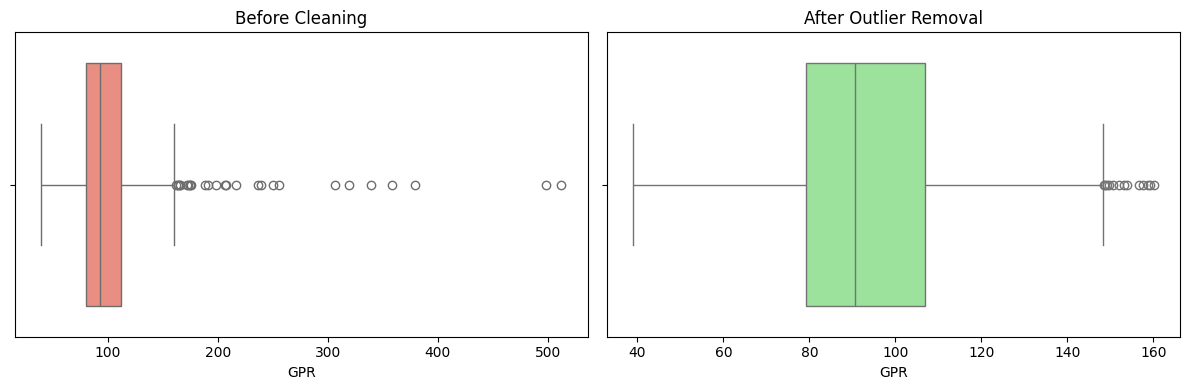

In [12]:
# 1. cleaning  the GPR series
# extracting the outlier using Inter Quartile Range


# filling the missing values by mean of the series
gpr.fillna(gpr.mean(), inplace=True)

# removing the outliers using inter quartile range
gpr_q1 = gpr['GPR'].quantile(0.25)
gpr_q3 = gpr['GPR'].quantile(0.75)
gpr_iqr = gpr_q3 - gpr_q1
gpr_lower_bound = gpr_q1 - 1.5 * gpr_iqr
gpr_upper_bound = gpr_q3 + 1.5 * gpr_iqr
print(f"GPR bounds: {gpr_lower_bound} to {gpr_upper_bound}")

# removing the outliers
gpr_clean = gpr[(gpr['GPR'] >= gpr_lower_bound) & (gpr['GPR'] <= gpr_upper_bound)].copy()
display(gpr_clean.describe())

# box plot - before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=gpr['GPR'], ax=axes[0], color='salmon')
axes[0].set_title('Before Cleaning')

sns.boxplot(x=gpr_clean['GPR'], ax=axes[1], color='lightgreen')
axes[1].set_title('After Outlier Removal')

plt.tight_layout()
plt.show()

### **Cleaning EUI**

EUI bounds: -0.1970353220000004 to 2.2566224580000007


,Energy_Uncertainty_Index
count,332.000000
mean,1.022397
std,0.444937
min,0.024819
25%,0.722214
50%,1.037716
75%,1.334504
max,2.132560


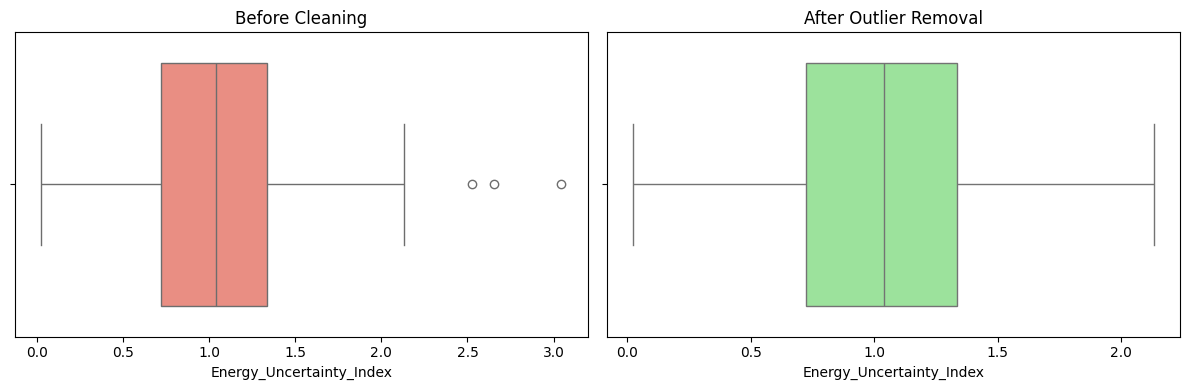

In [13]:
# 2. cleaning the EUI index


# replacing the missing values by mean of the series
energy_index.fillna(energy_index.mean(), inplace=True)

# removing the outliers using inter quartile range
eui_q1 = energy_index['Energy_Uncertainty_Index'].quantile(0.25)
eui_q3 = energy_index['Energy_Uncertainty_Index'].quantile(0.75)
eui_iqr = eui_q3 - eui_q1
eui_lower_bound = eui_q1 - 1.5 * eui_iqr
eui_upper_bound = eui_q3 + 1.5 * eui_iqr
print(f"EUI bounds: {eui_lower_bound} to {eui_upper_bound}")

# removing the outliers
energy_index_clean = energy_index[
    (energy_index['Energy_Uncertainty_Index'] >= eui_lower_bound) &
    (energy_index['Energy_Uncertainty_Index'] <= eui_upper_bound)
].copy()

display(energy_index_clean.describe())


# box plot - before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=energy_index['Energy_Uncertainty_Index'], ax=axes[0], color='salmon')
axes[0].set_title('Before Cleaning')

sns.boxplot(x=energy_index_clean['Energy_Uncertainty_Index'], ax=axes[1], color='lightgreen')
axes[1].set_title('After Outlier Removal')

plt.tight_layout()
plt.show()

### **Cleaning WTI**

WTI bounds: -14.040006637573242 to 142.68000984191895


,WTI_Close
count,5817.000000
mean,64.070899
std,25.427676
min,10.010000
25%,44.700001
50%,61.820000
75%,83.870003
max,141.649994


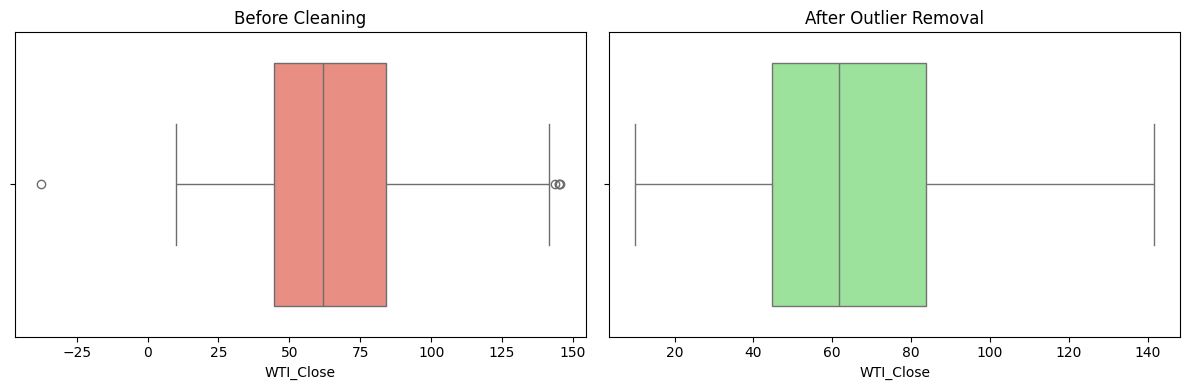

In [14]:
# 3. cleaning WTI Crude Oil

# replacing the missing values by the mean of the series
wti.fillna(wti.mean(), inplace=True)

# removing the outliers using Inter Quartile Range
wti_clean = wti[wti['WTI_Close'] > 0].copy()
wti_q1 = wti_clean['WTI_Close'].quantile(0.25)
wti_q3 = wti_clean['WTI_Close'].quantile(0.75)
wti_iqr = wti_q3 - wti_q1
wti_lower_bound = wti_q1 - 1.5 * wti_iqr
wti_upper_bound = wti_q3 + 1.5 * wti_iqr
print(f"WTI bounds: {wti_lower_bound} to {wti_upper_bound}")

wti_clean = wti_clean[(wti_clean['WTI_Close'] >= wti_lower_bound) & (wti_clean['WTI_Close'] <= wti_upper_bound)]


# WTI crude price: keep only realistic values (e.g. $5–$200 per barrel)
wti_clean = wti_clean[
    (wti_clean['WTI_Close'] > 5) &
    (wti_clean['WTI_Close'] < 200)].copy()

display(wti_clean.describe())

# box plot - before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=wti['WTI_Close'], ax=axes[0], color='salmon')
axes[0].set_title('Before Cleaning')

sns.boxplot(x=wti_clean['WTI_Close'], ax=axes[1], color='lightgreen')
axes[1].set_title('After Outlier Removal')

plt.tight_layout()
plt.show()

### **Cleaning US CPI**

CPI bounds: -216.25 to 447.54999999999995


,US CPI
count,942.000000
mean,122.785025
std,88.244421
min,21.480000
25%,32.675000
50%,109.450000
75%,198.625000
max,321.500000


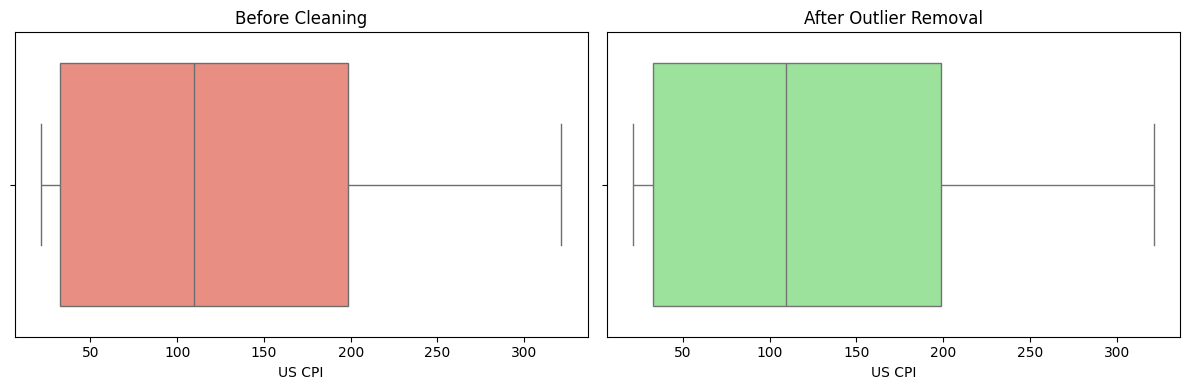

In [15]:
# 4. cleaning US CPI

# filling the missing values by the mean of the series and cleaning the  questionable / extreme values
cpi.fillna(cpi.mean(), inplace=True)


# CPI must be positive and reasonable
cpi_df = pd.DataFrame(cpi)
cpi_clean = cpi_df[cpi_df['US CPI'] > 0].copy()

# removing the outliers using interquartile range in all three datasets

# removing the outliers using Inter Quartile Range
cpi_q1 = cpi_clean['US CPI'].quantile(0.25)
cpi_q3 = cpi_clean['US CPI'].quantile(0.75)
cpi_iqr = cpi_q3 - cpi_q1
cpi_lower_bound = cpi_q1 - 1.5 * cpi_iqr
cpi_upper_bound = cpi_q3 + 1.5 * cpi_iqr
print(f"CPI bounds: {cpi_lower_bound} to {cpi_upper_bound}")

cpi_clean = cpi_clean[(cpi_clean['US CPI'] >= cpi_lower_bound) & (cpi_clean['US CPI'] <= cpi_upper_bound)]
display(cpi_clean.describe())

# box plot - before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=cpi_df['US CPI'], ax=axes[0], color='salmon')
axes[0].set_title('Before Cleaning')

sns.boxplot(x=cpi_clean['US CPI'], ax=axes[1], color='lightgreen')
axes[1].set_title('After Outlier Removal')

plt.tight_layout()
plt.show()

### **Cleaning US GDP**

GDP bounds: -4.350000000000001 to 10.650000000000002


,US GDP Growth Rate
count,293.000000
mean,3.256655
std,2.979335
min,-4.300000
25%,1.400000
50%,3.100000
75%,4.900000
max,10.300000


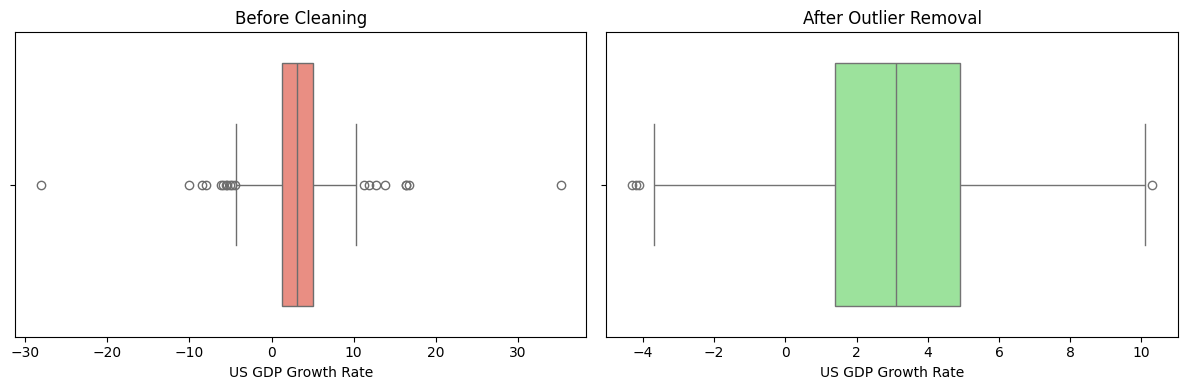

In [16]:
# 5. cleaning US GDP

# filling the missing values by the mean of the series and cleaning the  questionable / extreme values
gdp.fillna(gdp.mean(), inplace=True)

# GDP Growth Rate plausible range (-50% to +50%)
gdp_df = pd.DataFrame(gdp)
gdp_clean = gdp_df[
    (gdp_df['US GDP Growth Rate'] > -50) &
    (gdp_df['US GDP Growth Rate'] < 50)].copy()

# removing the outliers using Inter Quartile Range
gdp_q1 = gdp_clean['US GDP Growth Rate'].quantile(0.25)
gdp_q3 = gdp_clean['US GDP Growth Rate'].quantile(0.75)
gdp_iqr = gdp_q3 - gdp_q1
gdp_lower_bound = gdp_q1 - 1.5 * gdp_iqr
gdp_upper_bound = gdp_q3 + 1.5 * gdp_iqr
print(f"GDP bounds: {gdp_lower_bound} to {gdp_upper_bound}")

gdp_clean = gdp_clean[(gdp_clean['US GDP Growth Rate'] >= gdp_lower_bound) & (gdp_clean['US GDP Growth Rate'] <= gdp_upper_bound)]
display(gdp_clean.describe())

# box plot - before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=gdp_df['US GDP Growth Rate'], ax=axes[0], color='salmon')
axes[0].set_title('Before Cleaning')

sns.boxplot(x=gdp_clean['US GDP Growth Rate'], ax=axes[1], color='lightgreen')
axes[1].set_title('After Outlier Removal')

plt.tight_layout()
plt.show()

### **Cleaning VIX**

VIX bounds: 0.43500185012817383 to 38.074997425079346


,VIX_Close
count,6762.000000
mean,19.383645
std,6.098501
min,9.140000
25%,14.402500
50%,18.570000
75%,23.240000
max,38.020000


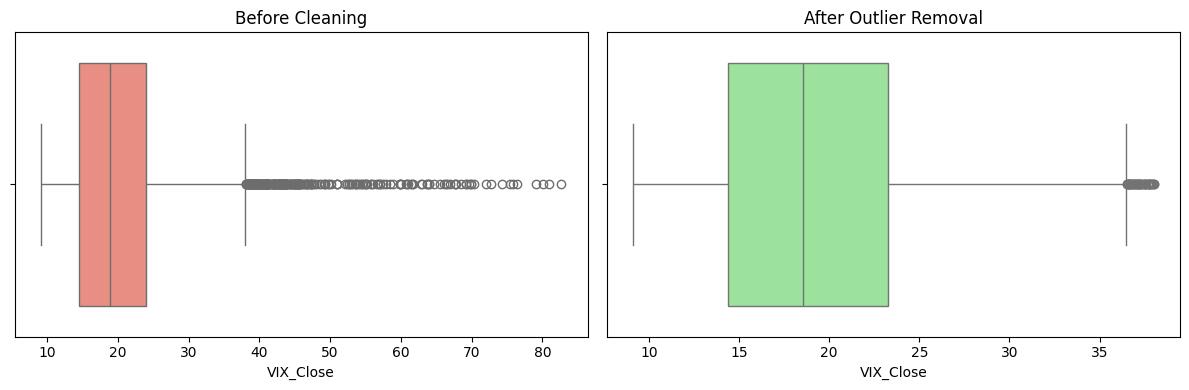

In [17]:
# 3. cleaning VIX Volatility Index

# replacing the missing values by the mean of the series
vix.fillna(vix.mean(), inplace=True)

# removing the outliers using Inter Quartile Range
vix_clean = vix[vix['VIX_Close'] > 0].copy()
vix_q1 = vix_clean['VIX_Close'].quantile(0.25)
vix_q3 = vix_clean['VIX_Close'].quantile(0.75)
vix_iqr = vix_q3 - vix_q1
vix_lower_bound = vix_q1 - 1.5 * vix_iqr
vix_upper_bound = vix_q3 + 1.5 * vix_iqr
print(f"VIX bounds: {vix_lower_bound} to {vix_upper_bound}")

vix_clean = vix_clean[(vix_clean['VIX_Close'] >= vix_lower_bound) & (vix_clean['VIX_Close'] <= vix_upper_bound)]


# VIX price: keep only realistic values (e.g. 0 – 100 )
vix_clean = vix_clean[
    (vix_clean['VIX_Close'] > 0) &
    (vix_clean['VIX_Close'] < 100)].copy()


display(vix_clean.describe())

# box plot - before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=vix['VIX_Close'], ax=axes[0], color='salmon')
axes[0].set_title('Before Cleaning')

sns.boxplot(x=vix_clean['VIX_Close'], ax=axes[1], color='lightgreen')
axes[1].set_title('After Outlier Removal')

plt.tight_layout()
plt.show()

### **Cleaning DXY**

DXY bounds: 59.480003356933594 to 123.15999603271484


,DXY_Close
count,7066.000000
mean,92.518872
std,10.761578
min,71.330002
25%,83.360001
50%,93.134998
75%,99.279999
max,120.900002


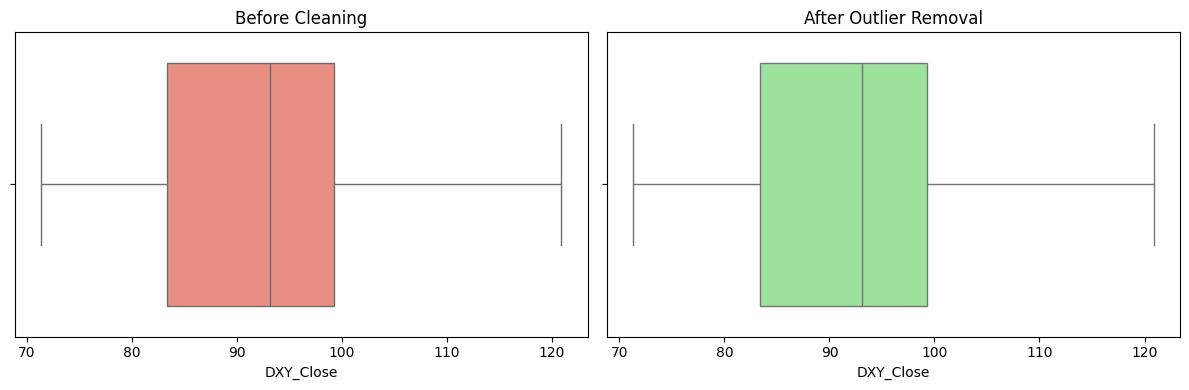

In [18]:
# 3. cleaning DXY US Dollar index

# replacing the missing values by the mean of the series
dxy.fillna(dxy.mean(), inplace=True)

# removing the outliers using Inter Quartile Range
dxy_clean = dxy[dxy['DXY_Close'] > 0].copy()
dxy_q1 = dxy_clean['DXY_Close'].quantile(0.25)
dxy_q3 = dxy_clean['DXY_Close'].quantile(0.75)
dxy_iqr = dxy_q3 - dxy_q1
dxy_lower_bound = dxy_q1 - 1.5 * dxy_iqr
dxy_upper_bound = dxy_q3 + 1.5 * dxy_iqr
print(f"DXY bounds: {dxy_lower_bound} to {dxy_upper_bound}")

dxy_clean = dxy_clean[(dxy_clean['DXY_Close'] >= dxy_lower_bound) & (dxy_clean['DXY_Close'] <= dxy_upper_bound)]


# DXY price: keep only realistic values (e.g. 50 – 150 )
dxy_clean = dxy_clean[
    (dxy_clean['DXY_Close'] > 50) &
    (dxy_clean['DXY_Close'] < 150)].copy()


display(dxy_clean.describe())

# box plot - before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=dxy['DXY_Close'], ax=axes[0], color='salmon')
axes[0].set_title('Before Cleaning')

sns.boxplot(x=dxy_clean['DXY_Close'], ax=axes[1], color='lightgreen')
axes[1].set_title('After Outlier Removal')

plt.tight_layout()
plt.show()

### **Cleaning RUR**

RUR IQR bounds: -143.49 to 414.81


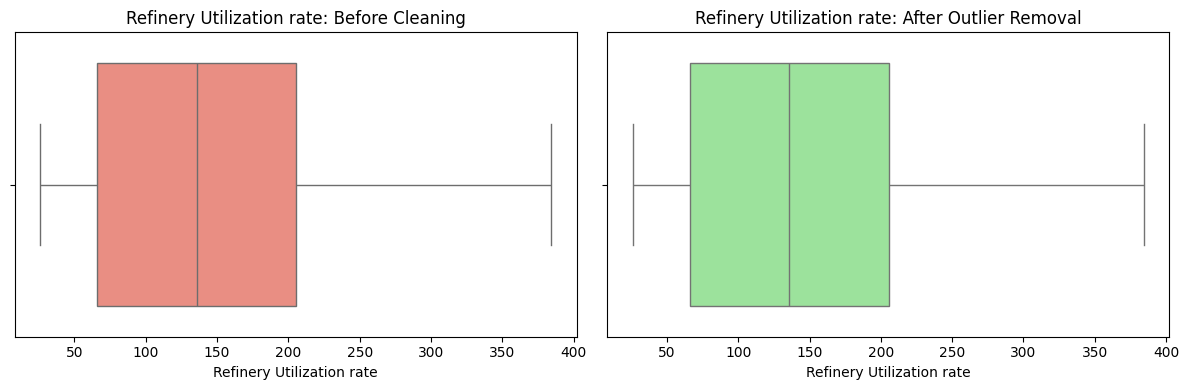

In [19]:
# 6. Cleaning Refinery Utilization Rate

rur_df = pd.DataFrame(rur)
rur_df.fillna(rur_df['Refinery Utilization rate'].mean(), inplace=True)

# Refinery Utilization Rate must be positive and reasonable
# RUR is a percentage, so values should inherently be positive.
# This step ensures no erroneous non-positive values remain.
rur_clean = rur_df[rur_df['Refinery Utilization rate'] > 0].copy()


# Removing the outliers using Inter Quartile Range
rur_q1 = rur_clean['Refinery Utilization rate'].quantile(0.25)
rur_q3 = rur_clean['Refinery Utilization rate'].quantile(0.75)
rur_iqr = rur_q3 - rur_q1
rur_lower_bound = rur_q1 - 1.5 * rur_iqr
rur_upper_bound = rur_q3 + 1.5 * rur_iqr

print(f"RUR IQR bounds: {rur_lower_bound:.2f} to {rur_upper_bound:.2f}")

rur_clean = rur_clean[(rur_clean['Refinery Utilization rate'] >= rur_lower_bound) &
                      (rur_clean['Refinery Utilization rate'] <= rur_upper_bound)]



# Box Plots - Before and After Cleaning ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=rur_df['Refinery Utilization rate'], ax=axes[0], color='salmon')
axes[0].set_title('Refinery Utilization rate: Before Cleaning')
axes[0].set_xlabel('Refinery Utilization rate')

sns.boxplot(x=rur_clean['Refinery Utilization rate'], ax=axes[1], color='lightgreen')
axes[1].set_title('Refinery Utilization rate: After Outlier Removal')
axes[1].set_xlabel('Refinery Utilization rate')

plt.tight_layout()
plt.show()

### **Cleaning WCESTUS1**

WCESTUS1 IQR bounds: 212248.00 to 458904.00


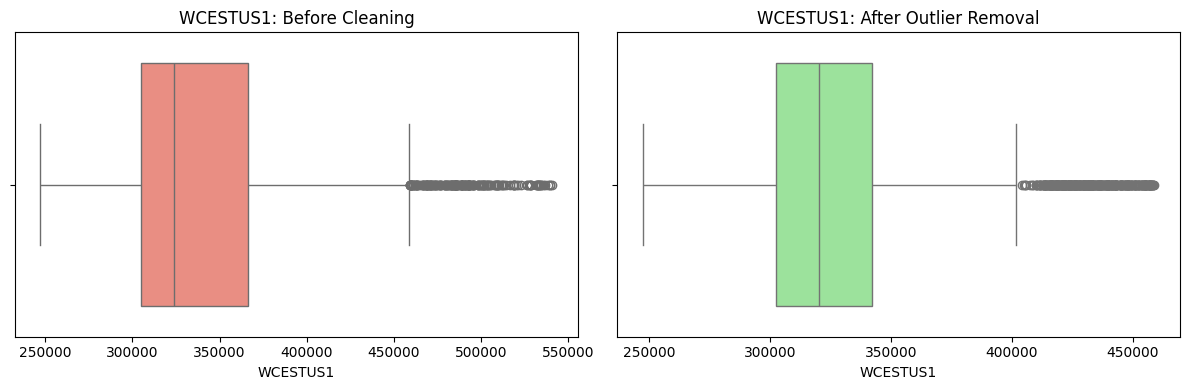

In [20]:
# 6. Cleaning WCESTUS1


wcest.fillna(wcest['WCESTUS1'].mean(), inplace=True)

# US Oil reserce stock must be positive and reasonable
# This step ensures no erroneous non-positive values remain.
wcest_clean = wcest[wcest['WCESTUS1'] > 0].copy()


# Removing the outliers using Inter Quartile Range
wcest_q1 = wcest_clean['WCESTUS1'].quantile(0.25)
wcest_q3 = wcest_clean['WCESTUS1'].quantile(0.75)
wcest_iqr = wcest_q3 - wcest_q1
wcest_lower_bound = wcest_q1 - 1.5 * wcest_iqr
wcest_upper_bound = wcest_q3 + 1.5 * wcest_iqr

print(f"WCESTUS1 IQR bounds: {wcest_lower_bound:.2f} to {wcest_upper_bound:.2f}")

wcest_clean = wcest_clean[(wcest_clean['WCESTUS1'] >= wcest_lower_bound) &
                      (wcest_clean['WCESTUS1'] <= wcest_upper_bound)]



# Box Plots - Before and After Cleaning ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=wcest['WCESTUS1'], ax=axes[0], color='salmon')
axes[0].set_title('WCESTUS1: Before Cleaning')
axes[0].set_xlabel('WCESTUS1')

sns.boxplot(x=wcest_clean['WCESTUS1'], ax=axes[1], color='lightgreen')
axes[1].set_title('WCESTUS1: After Outlier Removal')
axes[1].set_xlabel('WCESTUS1')

plt.tight_layout()
plt.show()

### Merging all datasets

In [21]:
# merging all the datasets - preparing the steralized version

for df in [gpr_clean, energy_index_clean, wti_clean, cpi_clean, gdp_clean, rur_clean, vix_clean, dxy_clean, wcest_clean]:
    df.index = pd.to_datetime(df.index)


# Resample all to monthly (end of month)
gpr_monthly = gpr_clean.resample('M').mean()
eui_monthly = energy_index_clean.resample('M').mean()
wti_monthly = wti_clean.resample('M').mean()
cpi_monthly = cpi_clean.resample('M').mean()
gdp_monthly = gdp_clean.resample('M').mean()
rur_monthly = rur_clean.resample('M').mean()
vix_monthly = vix_clean.resample('M').mean()
dxy_monthly = dxy_clean.resample('M').mean()
wcest_monthly = wcest_clean.resample('M').mean()



df_merged = pd.concat([gpr_monthly, eui_monthly, wti_monthly, cpi_monthly, gdp_monthly, rur_monthly, vix_monthly, dxy_monthly, wcest_monthly], axis=1, join='inner')
df_merged.columns = ['GPR', 'EUI', 'WTI', 'CPI', 'GDP', 'RUR', 'VIX', 'DXY', 'WCEST']
df_merged['GDP'] = df_merged['GDP'].ffill()
df_merged.dropna(inplace=True)
df_merged.head()

,GPR,EUI,WTI,CPI,GDP,RUR,VIX,DXY,WCEST
2000-10-31,76.456528,1.201645,32.973182,173.9,2.4,93.1,25.200000,116.051364,269194.50
2000-11-30,45.060562,1.403604,34.264500,174.2,2.4,98.8,26.382857,116.475908,270779.25
2000-12-31,45.395100,0.970674,28.355000,174.6,2.4,78.8,26.530500,112.725000,274451.80
2001-01-31,46.899555,1.031300,29.266667,175.6,-1.3,75.4,24.918571,110.125909,269867.00
2001-02-28,55.087711,1.024682,29.644210,176.0,-1.3,80.7,23.411579,111.805499,266600.75


In [22]:
df_merged.to_csv('merged_dataset.csv')

## **Step - 7 - EDA**

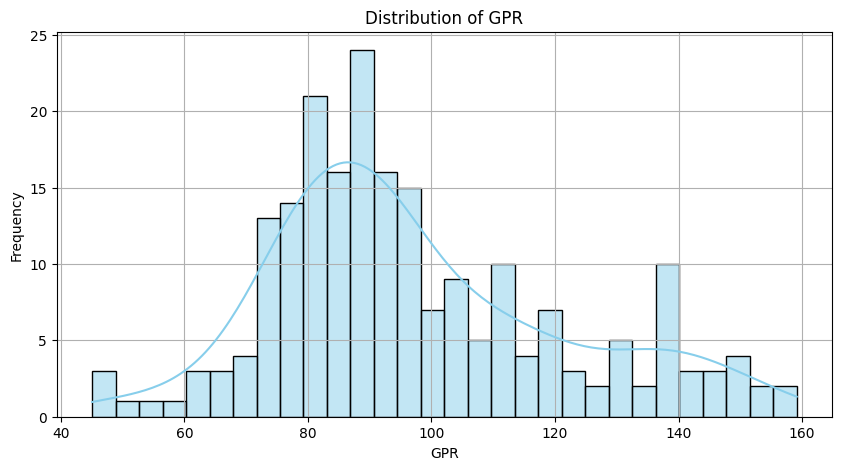

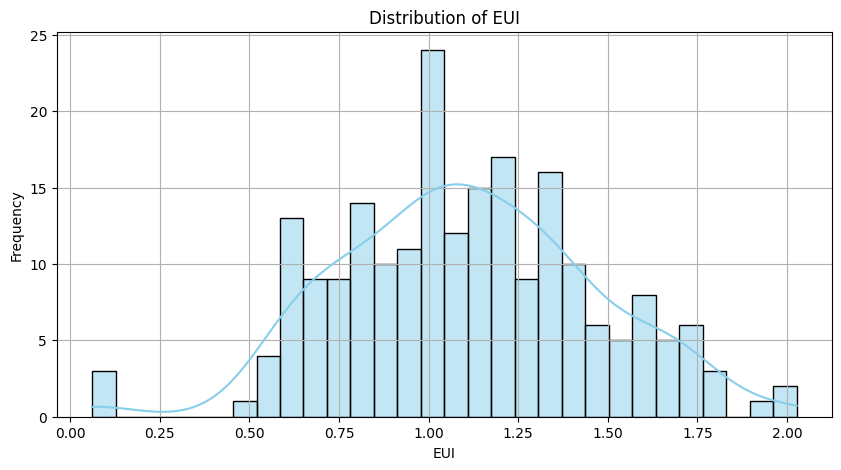

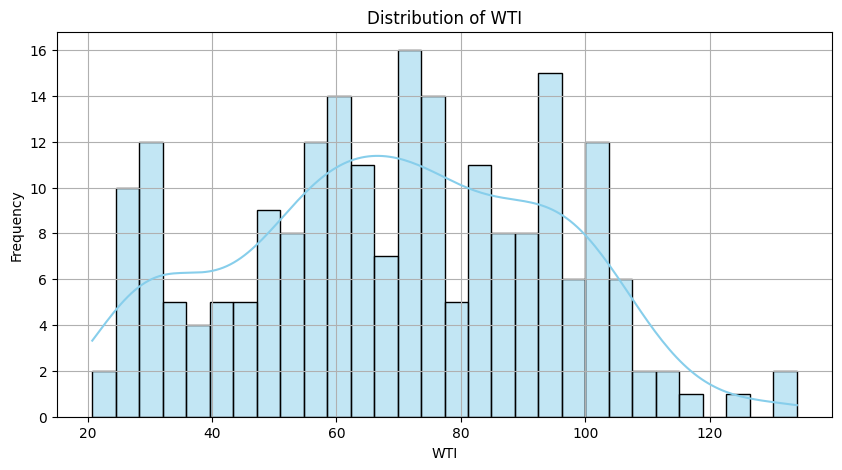

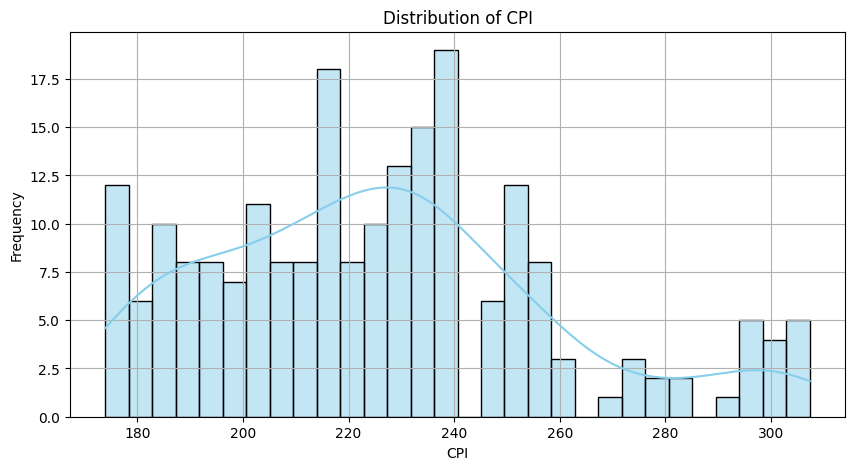

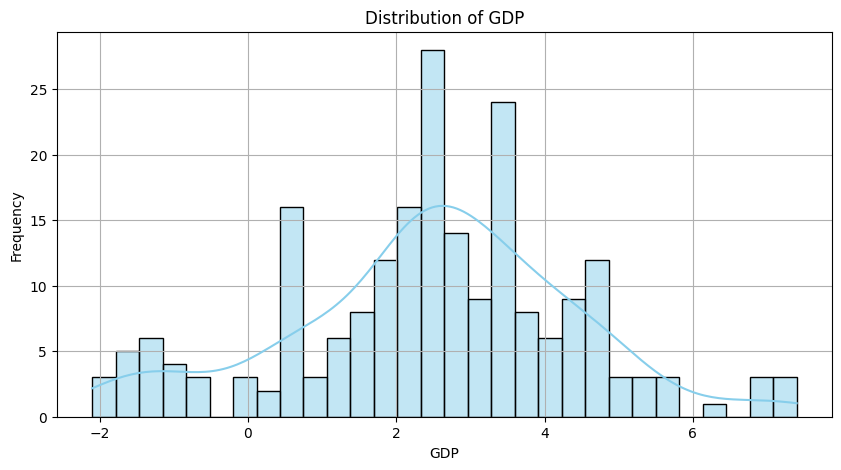

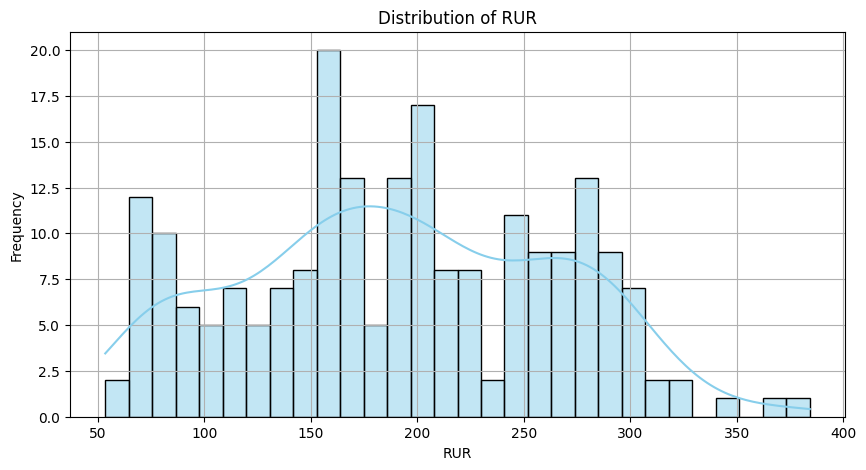

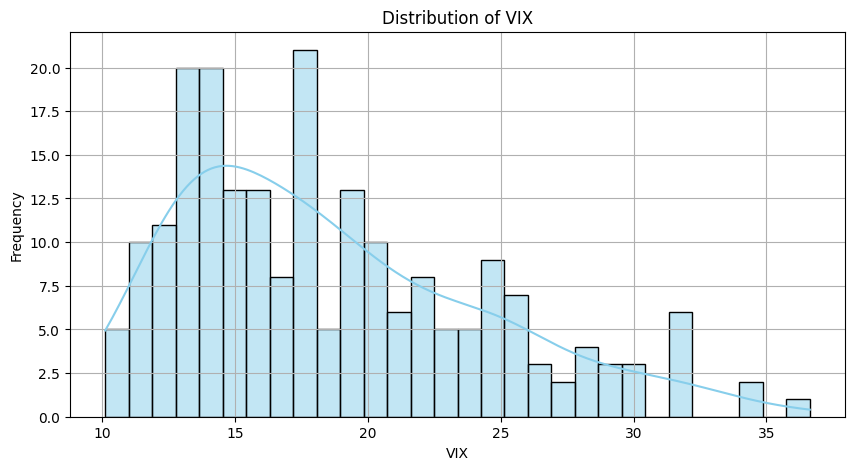

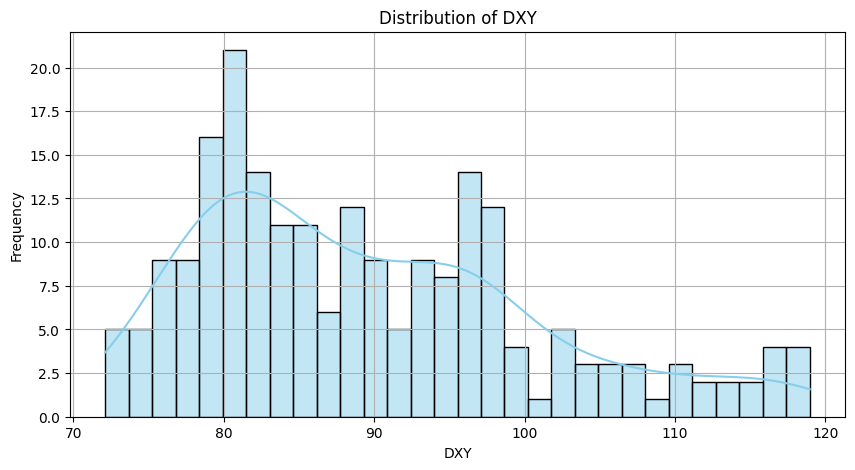

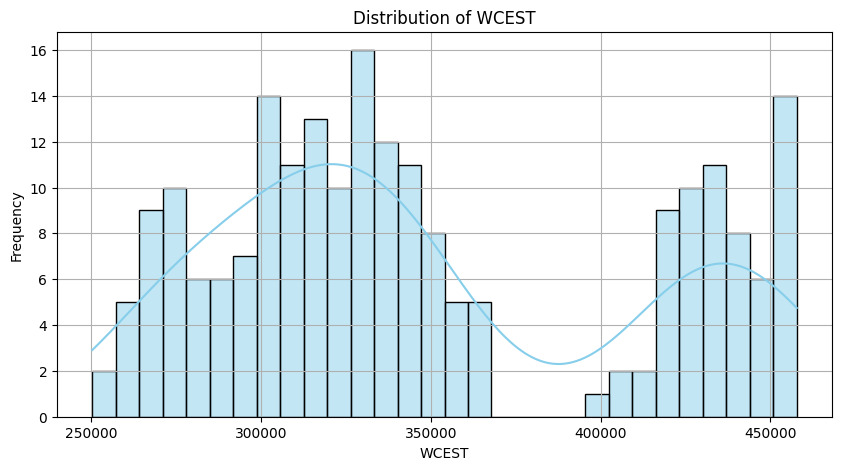

In [ ]:
# plotting on the cleaned datasets

# distribution plots - histograms + KDE for each series

for col in df_merged.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df_merged[col], bins=30, kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

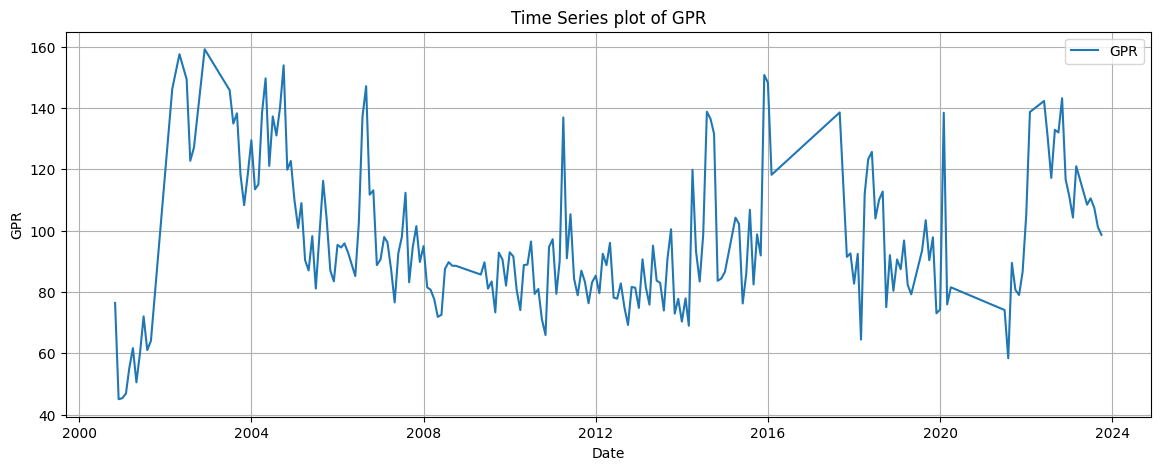

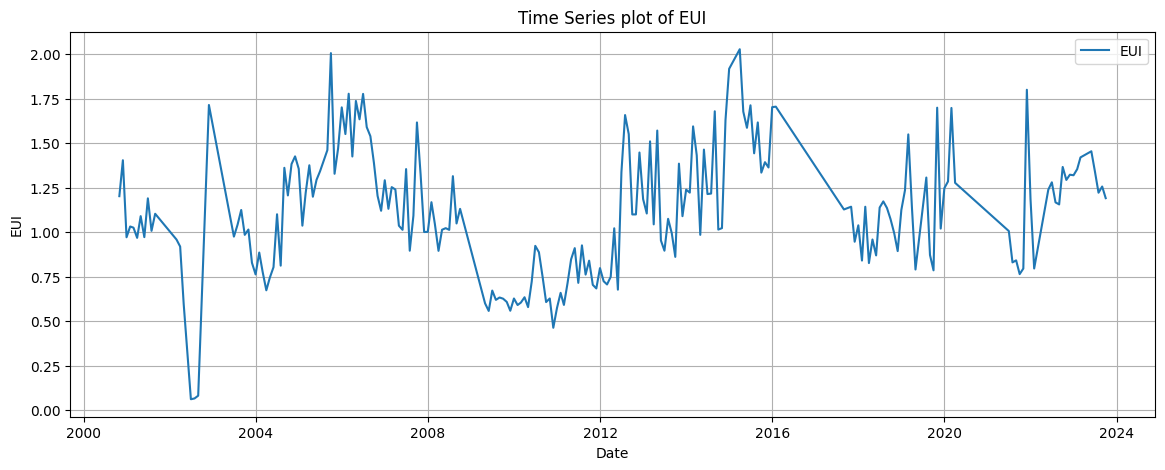

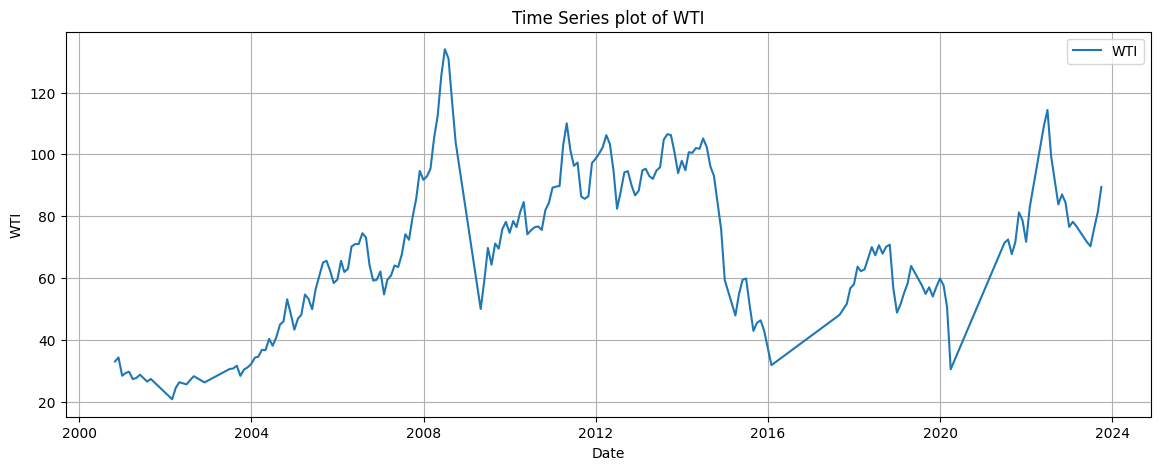

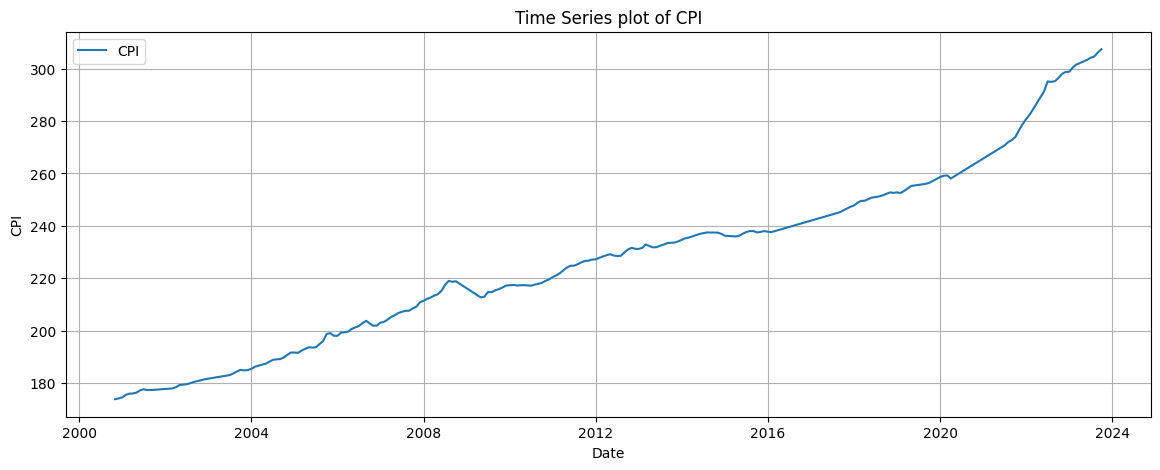

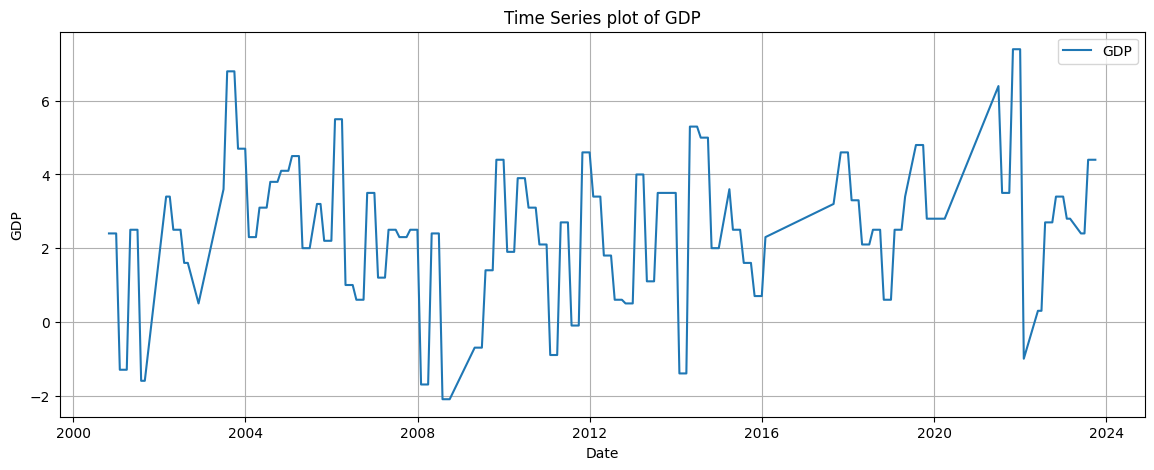

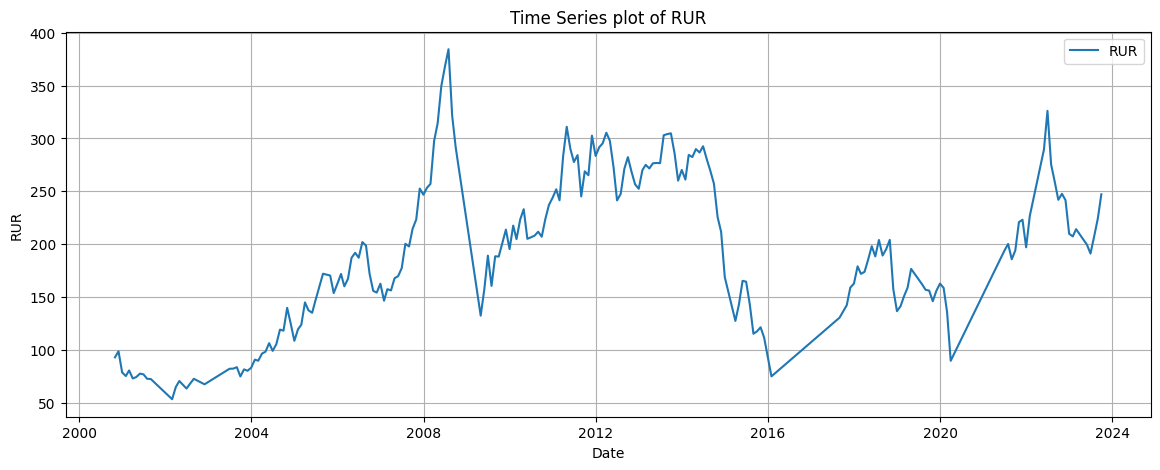

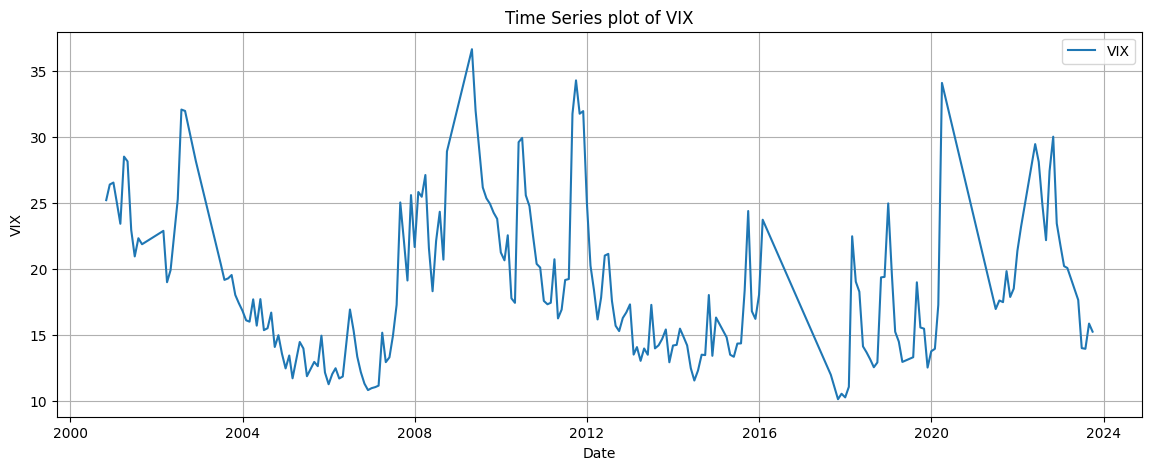

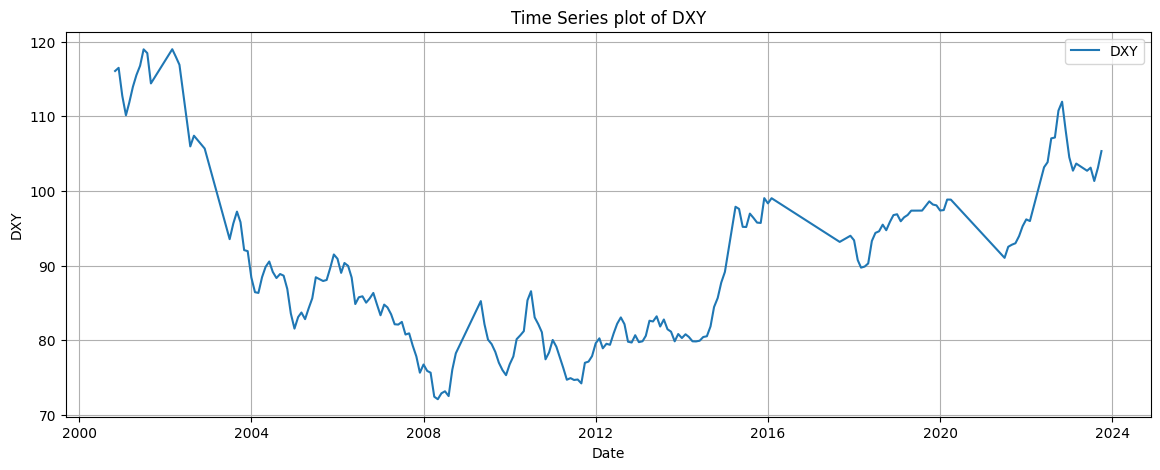

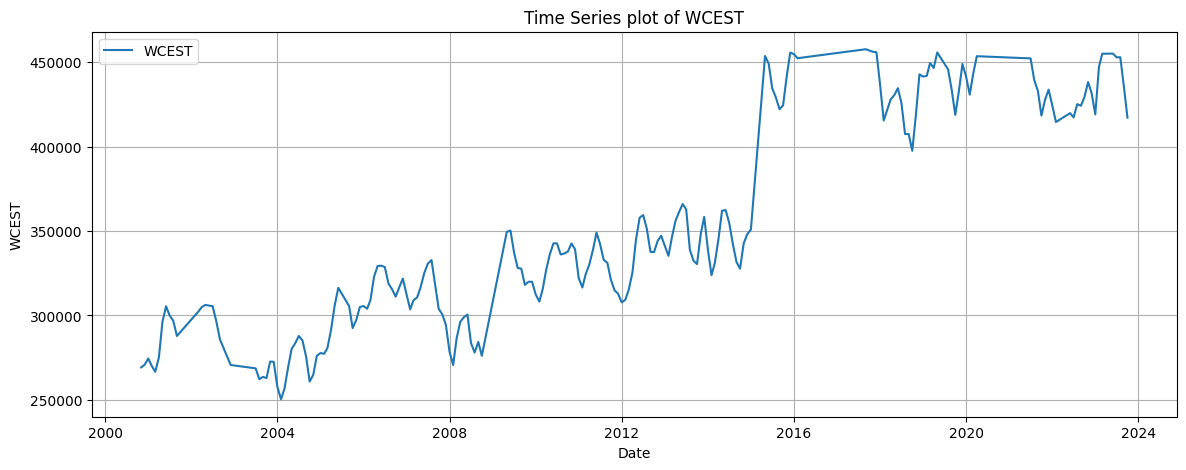

In [ ]:
# Time-series plots
for col in df_merged.columns:
  plt.figure(figsize=(14, 5))
  plt.plot(df_merged.index, df_merged[col], label = col)
  plt.title(f'Time Series plot of {col}')
  plt.xlabel('Date')
  plt.ylabel(col)
  plt.grid(True)
  plt.legend()
  plt.show()

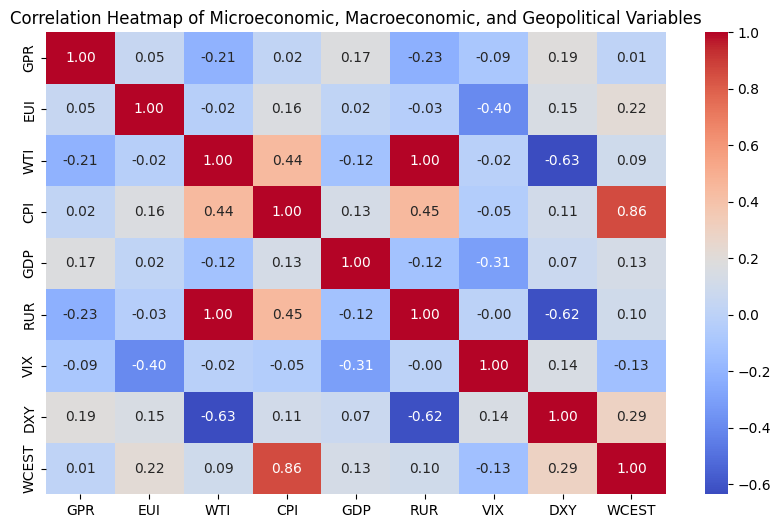

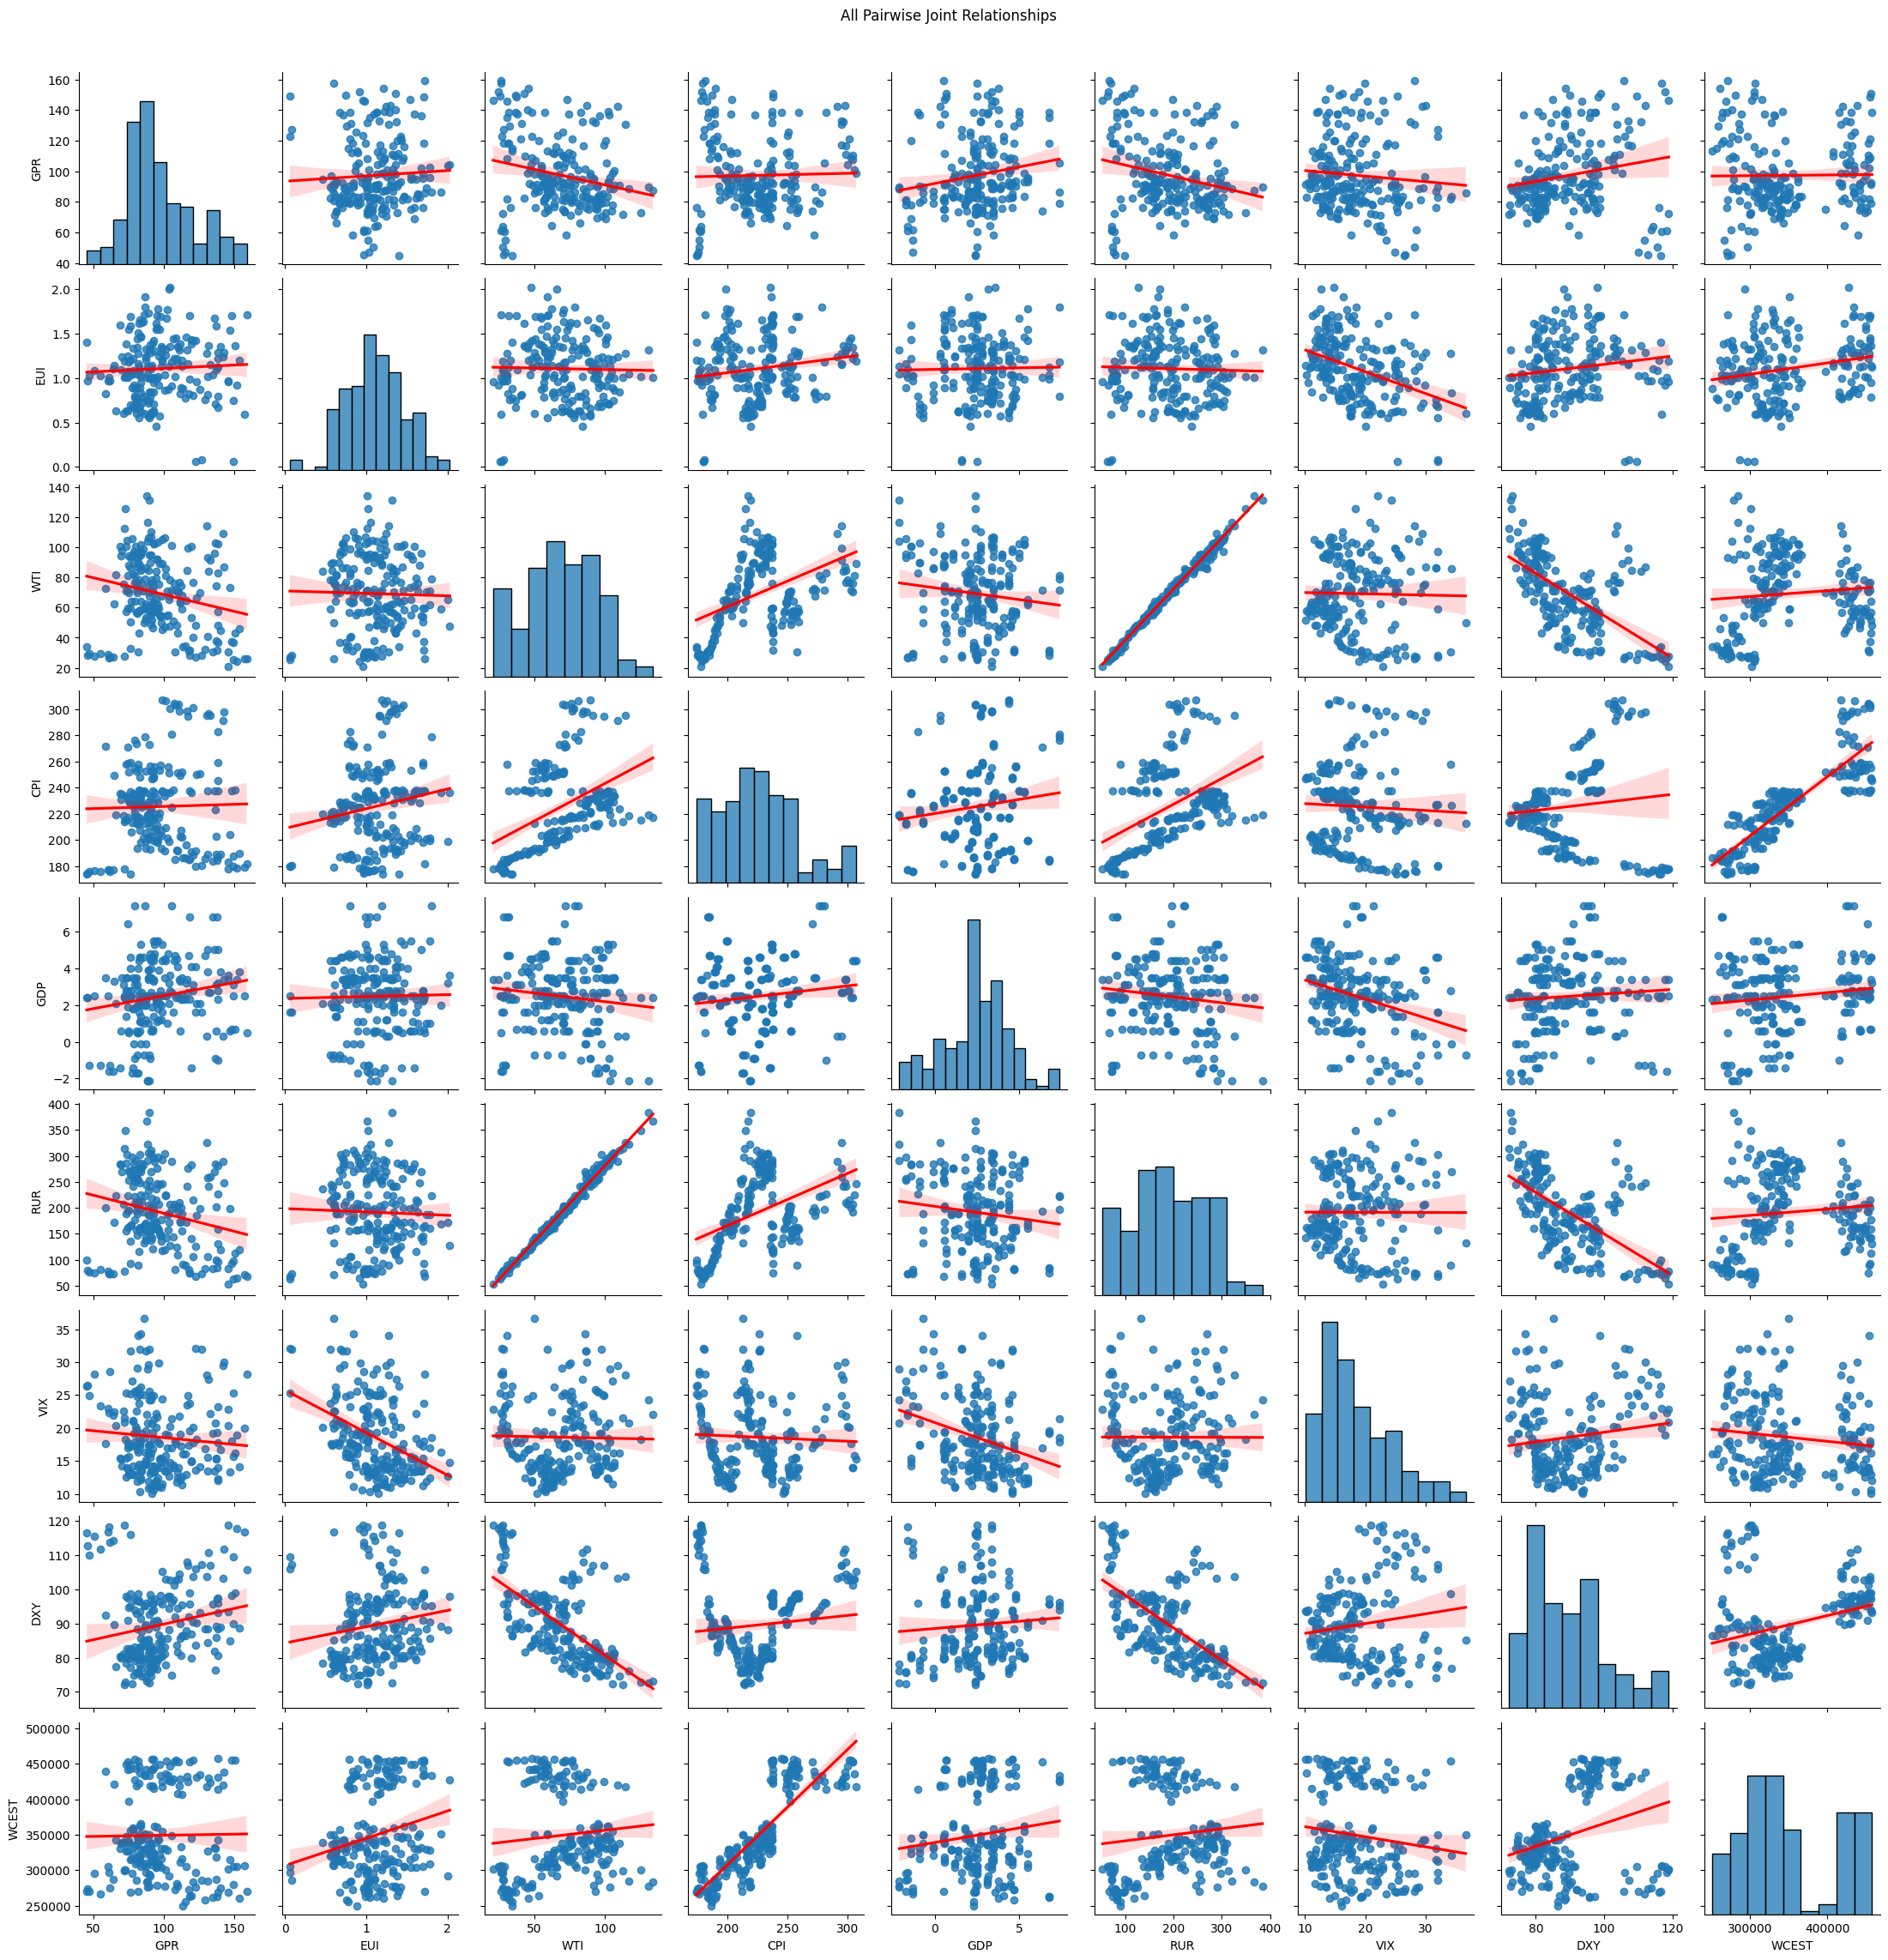

In [ ]:
# Multivariate plots

# correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_merged.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Microeconomic, Macroeconomic, and Geopolitical Variables")
plt.show()


# pairplot
sns.pairplot(df_merged, kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle("All Pairwise Joint Relationships", y=1.02)
plt.show()

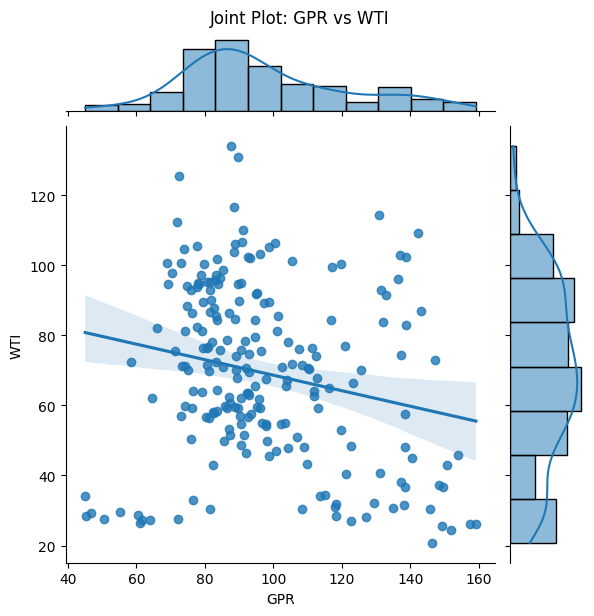

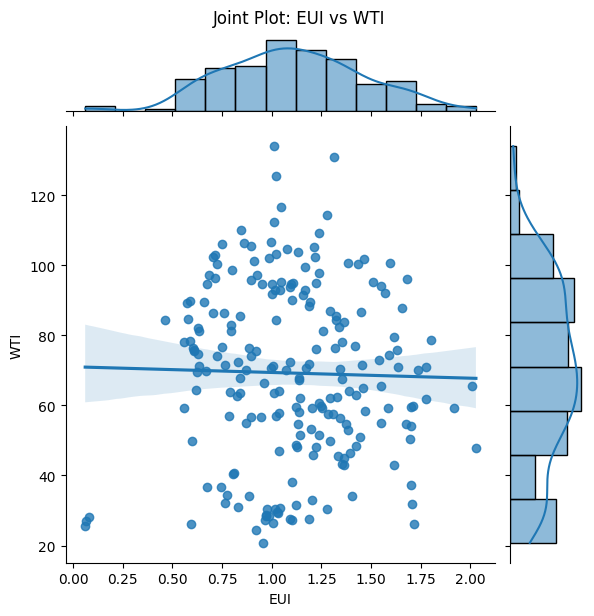

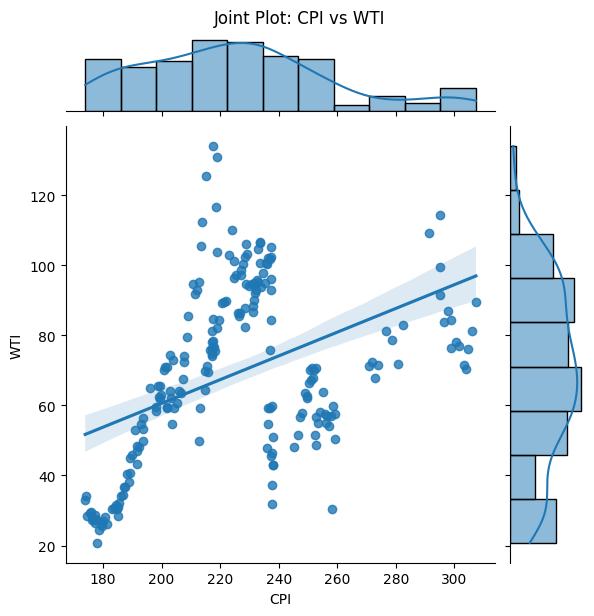

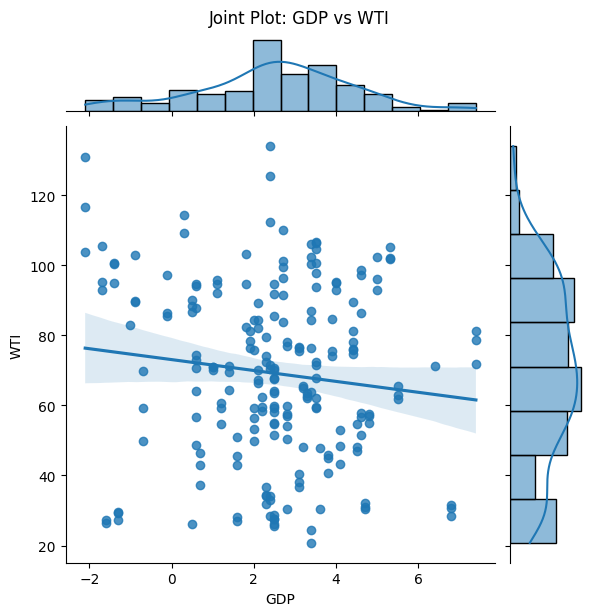

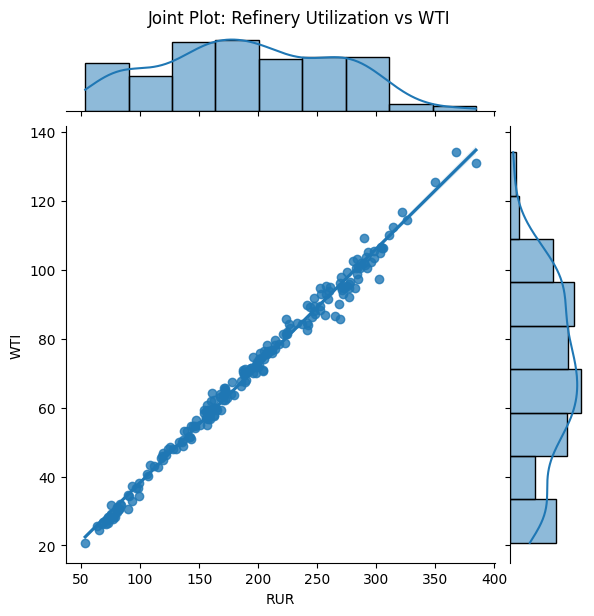

In [ ]:
# selected joint plots

# GPR vs WTI
sns.jointplot(data=df_merged, x='GPR', y='WTI', kind='reg', height=6)
plt.suptitle("Joint Plot: GPR vs WTI", y=1.02)
plt.show()

# EUI vs WTI — Energy uncertainty's impact on oil price
sns.jointplot(data=df_merged, x='EUI', y='WTI', kind='reg', height=6)
plt.suptitle("Joint Plot: EUI vs WTI", y=1.02)
plt.show()

# CPI vs WTI — inflation dynamics and oil
sns.jointplot(data=df_merged, x='CPI', y='WTI', kind='reg', height=6)
plt.suptitle("Joint Plot: CPI vs WTI", y=1.02)
plt.show()

# GDP vs WTI — economic growth and oil prices
sns.jointplot(data=df_merged, x='GDP', y='WTI', kind='reg', height=6)
plt.suptitle("Joint Plot: GDP vs WTI", y=1.02)
plt.show()

# joint plot of refinery utilization vs WTI
sns.jointplot(data=df_merged, x='RUR', y='WTI', kind='reg', height=6)
plt.suptitle("Joint Plot: Refinery Utilization vs WTI", y=1.02)
plt.show()

<Figure size 1000x400 with 0 Axes>

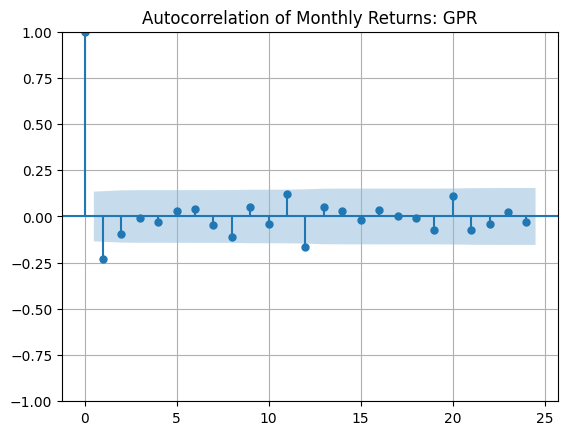

<Figure size 1000x400 with 0 Axes>

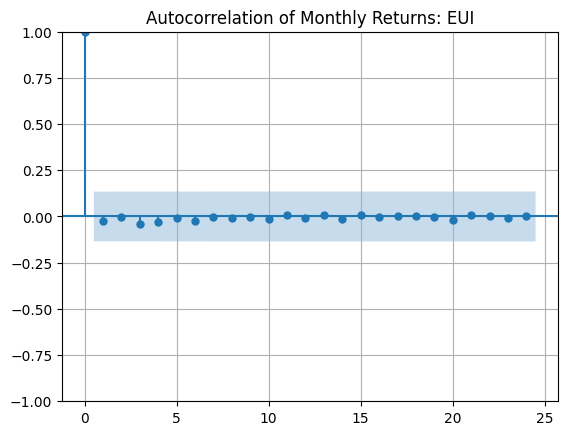

<Figure size 1000x400 with 0 Axes>

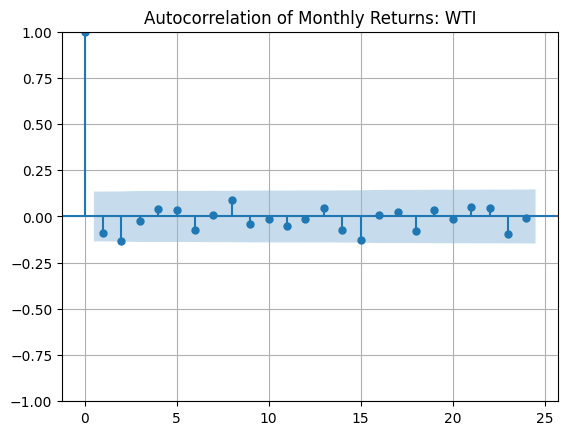

<Figure size 1000x400 with 0 Axes>

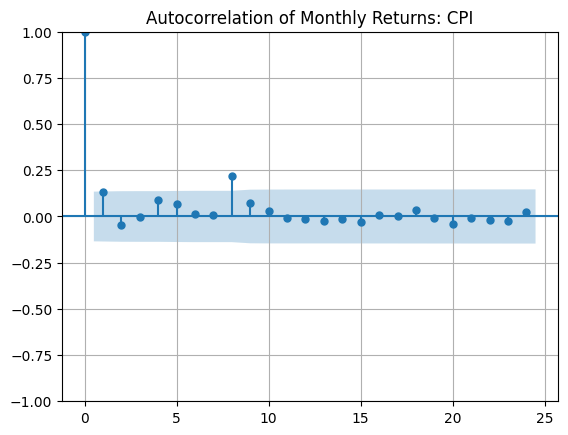

<Figure size 1000x400 with 0 Axes>

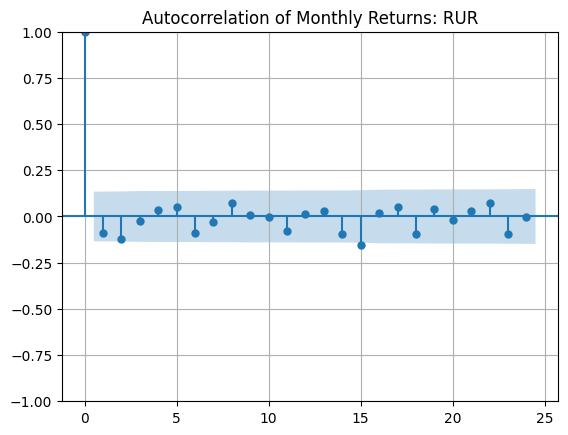

<Figure size 1000x400 with 0 Axes>

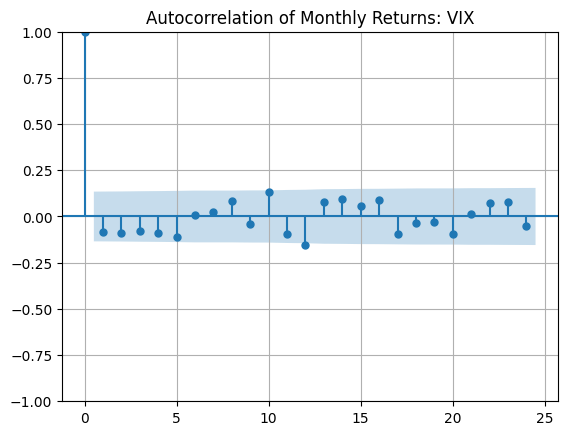

<Figure size 1000x400 with 0 Axes>

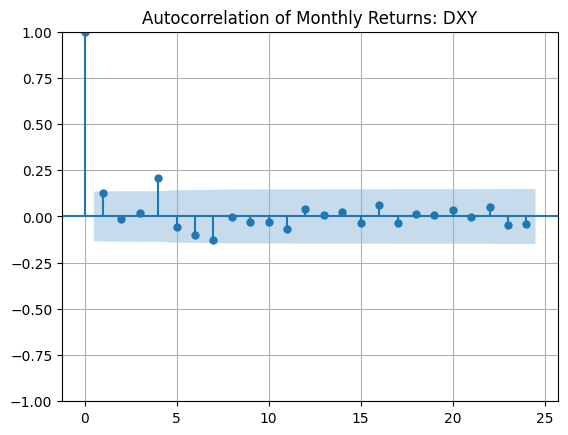

<Figure size 1000x400 with 0 Axes>

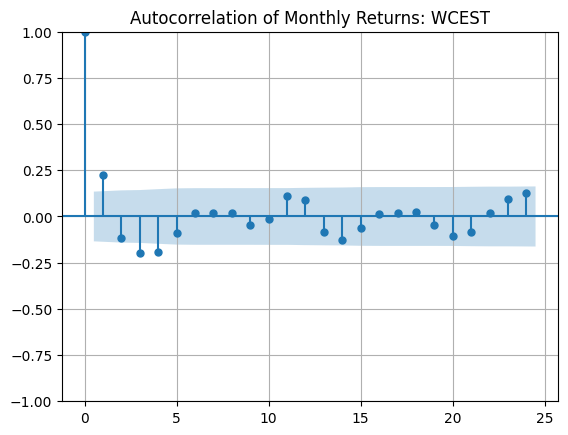

<Figure size 1000x400 with 0 Axes>

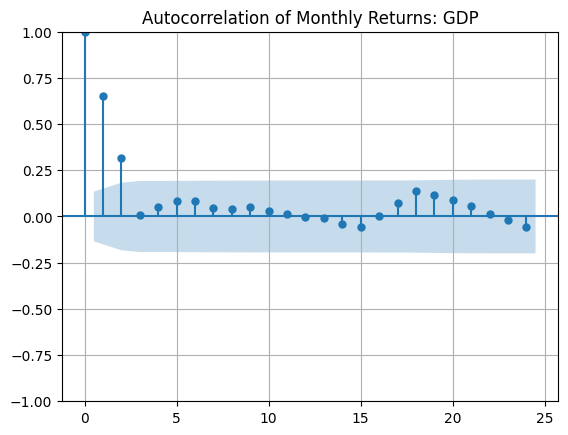

In [ ]:
returns = df_merged[['GPR', 'EUI', 'WTI', 'CPI', 'RUR', 'VIX', 'DXY', 'WCEST']].pct_change()
returns['GDP'] = df_merged['GDP']
returns.dropna(inplace=True)

# plotting ACF for each return series
for col in returns.columns:
    plt.figure(figsize=(10, 4))
    plot_acf(returns[col], lags=24, alpha=0.05)
    plt.title(f"Autocorrelation of Monthly Returns: {col}")
    plt.grid(True)
    plt.show()

In [ ]:
# the remaining steps can be found in the google doc.